# Exploratory Data Analysis Starter

## Import packages

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Shows plots in jupyter notebook
%matplotlib inline

# Set plot style
sns.set(color_codes=True)

---

## Loading data with Pandas

We need to load `client_data.csv` and `price_data.csv` into individual dataframes so that we can work with them in Python. For this notebook and all further notebooks, it will be assumed that the CSV files will the placed in the same file location as the notebook. If they are not, please adjust the directory within the `read_csv` method accordingly.

In [ ]:
client_data = pd.read_csv('/content/client_data (1).csv')
price_data = pd.read_csv('/content/price_data (1).csv')

You can view the first 3 rows of a dataframe using the `head` method. Similarly, if you wanted to see the last 3, you can use `tail(3)`

In [ ]:
client_df.head(3)

,id,channel_sales,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,...,has_gas,imp_cons,margin_gross_pow_ele,margin_net_pow_ele,nb_prod_act,net_margin,num_years_antig,origin_up,pow_max,churn
0,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.00,...,t,0.0,25.44,25.44,2,678.99,3,lxidpiddsbxsbosboudacockeimpuepw,43.648,1
1,d29c2c54acc38ff3c0614d0a653813dd,MISSING,4660,0,0,2009-08-21,2016-08-30,2009-08-21,2015-08-31,189.95,...,f,0.0,16.38,16.38,1,18.89,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.800,0
2,764c75f661154dac3a6c254cd082ea7d,foosdfpfkusacimwkcsosbicdxkicaua,544,0,0,2010-04-16,2016-04-16,2010-04-16,2015-04-17,47.96,...,f,0.0,28.60,28.60,1,6.60,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.856,0


In [ ]:
price_df.head(3)

,id,price_date,price_off_peak_var,price_peak_var,price_mid_peak_var,price_off_peak_fix,price_peak_fix,price_mid_peak_fix
0,038af19179925da21a25619c5a24b745,2015-01-01,0.151367,0.0,0.0,44.266931,0.0,0.0
1,038af19179925da21a25619c5a24b745,2015-02-01,0.151367,0.0,0.0,44.266931,0.0,0.0
2,038af19179925da21a25619c5a24b745,2015-03-01,0.151367,0.0,0.0,44.266931,0.0,0.0


---

## Descriptive statistics of data

### Data types

It is useful to first understand the data that you're dealing with along with the data types of each column. The data types may dictate how you transform and engineer features.

To get an overview of the data types within a data frame, use the `info()` method.

In [ ]:
client_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14606 entries, 0 to 14605
Data columns (total 26 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              14606 non-null  object 
 1   channel_sales                   14606 non-null  object 
 2   cons_12m                        14606 non-null  int64  
 3   cons_gas_12m                    14606 non-null  int64  
 4   cons_last_month                 14606 non-null  int64  
 5   date_activ                      14606 non-null  object 
 6   date_end                        14606 non-null  object 
 7   date_modif_prod                 14606 non-null  object 
 8   date_renewal                    14606 non-null  object 
 9   forecast_cons_12m               14606 non-null  float64
 10  forecast_cons_year              14606 non-null  int64  
 11  forecast_discount_energy        14606 non-null  float64
 12  forecast_meter_rent_12m         

In [ ]:
price_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 193002 entries, 0 to 193001
Data columns (total 8 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   id                  193002 non-null  object 
 1   price_date          193002 non-null  object 
 2   price_off_peak_var  193002 non-null  float64
 3   price_peak_var      193002 non-null  float64
 4   price_mid_peak_var  193002 non-null  float64
 5   price_off_peak_fix  193002 non-null  float64
 6   price_peak_fix      193002 non-null  float64
 7   price_mid_peak_fix  193002 non-null  float64
dtypes: float64(6), object(2)
memory usage: 11.8+ MB


### Statistics

Now let's look at some statistics about the datasets. We can do this by using the `describe()` method.

In [ ]:
client_data.describe()

,cons_12m,cons_gas_12m,cons_last_month,forecast_cons_12m,forecast_cons_year,forecast_discount_energy,forecast_meter_rent_12m,forecast_price_energy_off_peak,forecast_price_energy_peak,forecast_price_pow_off_peak,imp_cons,margin_gross_pow_ele,margin_net_pow_ele,nb_prod_act,net_margin,num_years_antig,pow_max,churn
count,1.460600e+04,1.460600e+04,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000
mean,1.592203e+05,2.809238e+04,16090.269752,1868.614880,1399.762906,0.966726,63.086871,0.137283,0.050491,43.130056,152.786896,24.565121,24.562517,1.292346,189.264522,4.997809,18.135136,0.097152
std,5.734653e+05,1.629731e+05,64364.196422,2387.571531,3247.786255,5.108289,66.165783,0.024623,0.049037,4.485988,341.369366,20.231172,20.230280,0.709774,311.798130,1.611749,13.534743,0.296175
min,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,3.300000,0.000000
25%,5.674750e+03,0.000000e+00,0.000000,494.995000,0.000000,0.000000,16.180000,0.116340,0.000000,40.606701,0.000000,14.280000,14.280000,1.000000,50.712500,4.000000,12.500000,0.000000
50%,1.411550e+04,0.000000e+00,792.500000,1112.875000,314.000000,0.000000,18.795000,0.143166,0.084138,44.311378,37.395000,21.640000,21.640000,1.000000,112.530000,5.000000,13.856000,0.000000
75%,4.076375e+04,0.000000e+00,3383.000000,2401.790000,1745.750000,0.000000,131.030000,0.146348,0.098837,44.311378,193.980000,29.880000,29.880000,1.000000,243.097500,6.000000,19.172500,0.000000
max,6.207104e+06,4.154590e+06,771203.000000,82902.830000,175375.000000,30.000000,599.310000,0.273963,0.195975,59.266378,15042.790000,374.640000,374.640000,32.000000,24570.650000,13.000000,320.000000,1.000000


In [ ]:
price_data.describe()

,price_off_peak_var,price_peak_var,price_mid_peak_var,price_off_peak_fix,price_peak_fix,price_mid_peak_fix
count,193002.000000,193002.000000,193002.000000,193002.000000,193002.000000,193002.000000
mean,0.141027,0.054630,0.030496,43.334477,10.622875,6.409984
std,0.025032,0.049924,0.036298,5.410297,12.841895,7.773592
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.125976,0.000000,0.000000,40.728885,0.000000,0.000000
50%,0.146033,0.085483,0.000000,44.266930,0.000000,0.000000
75%,0.151635,0.101673,0.072558,44.444710,24.339581,16.226389
max,0.280700,0.229788,0.114102,59.444710,36.490692,17.458221


---

## Data visualization

If you're working in Python, two of the most popular packages for visualization are `matplotlib` and `seaborn`. We highly recommend you use these, or at least be familiar with them because they are ubiquitous!

Below are some functions that you can use to get started with visualizations.

In [ ]:
def plot_stacked_bars(dataframe, title_, size_=(18, 10), rot_=0, legend_="upper right"):
    """
    Plot stacked bars with annotations
    """
    ax = dataframe.plot(
        kind="bar",
        stacked=True,
        figsize=size_,
        rot=rot_,
        title=title_
    )

    # Annotate bars
    annotate_stacked_bars(ax, textsize=14)
    # Rename legend
    plt.legend(["Retention", "Churn"], loc=legend_)
    # Labels
    plt.ylabel("Company base (%)")
    plt.show()

def annotate_stacked_bars(ax, pad=0.99, colour="white", textsize=13):
    """
    Add value annotations to the bars
    """

    # Iterate over the plotted rectanges/bars
    for p in ax.patches:

        # Calculate annotation
        value = str(round(p.get_height(),1))
        # If value is 0 do not annotate
        if value == '0.0':
            continue
        ax.annotate(
            value,
            ((p.get_x()+ p.get_width()/2)*pad-0.05, (p.get_y()+p.get_height()/2)*pad),
            color=colour,
            size=textsize
        )

def plot_distribution(dataframe, column, ax, bins_=50):
    """
    Plot variable distirbution in a stacked histogram of churned or retained company
    """
    # Create a temporal dataframe with the data to be plot
    temp = pd.DataFrame({"Retention": dataframe[dataframe["churn"]==0][column],
    "Churn":dataframe[dataframe["churn"]==1][column]})
    # Plot the histogram
    temp[["Retention","Churn"]].plot(kind='hist', bins=bins_, ax=ax, stacked=True)
    # X-axis label
    ax.set_xlabel(column)
    # Change the x-axis to plain style
    ax.ticklabel_format(style='plain', axis='x')

Thhe first function `plot_stacked_bars` is used to plot a stacked bar chart. An example of how you could use this is shown below:

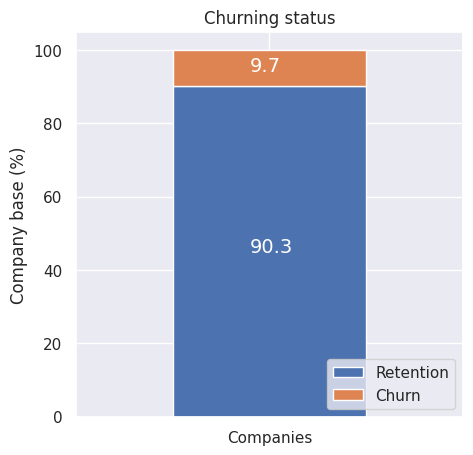

In [ ]:
churn = client_data[['id', 'churn']]
churn.columns = ['Companies', 'churn']
churn_total = churn.groupby(churn['churn']).count()
churn_percentage = churn_total / churn_total.sum() * 100
plot_stacked_bars(churn_percentage.transpose(), "Churning status", (5, 5), legend_="lower right")

The second function `annotate_bars` is used by the first function, but the third function `plot_distribution` helps you to plot the distribution of a numeric column. An example of how it can be used is given below:

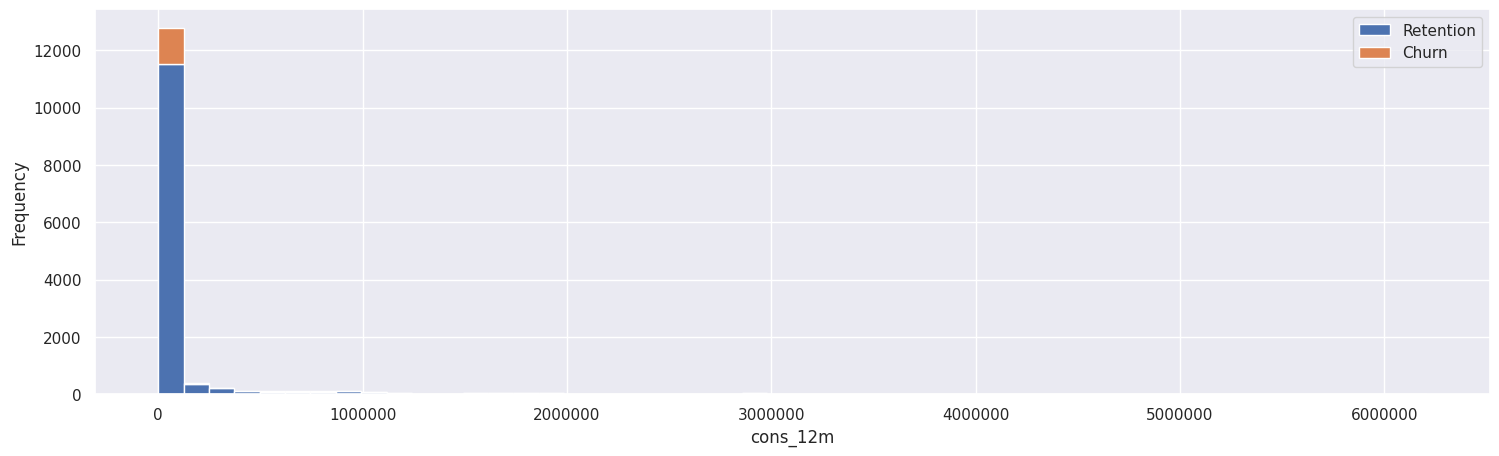

In [ ]:
consumption = client_data[['id', 'cons_12m', 'cons_gas_12m', 'cons_last_month', 'imp_cons', 'has_gas', 'churn']]

fig, axs = plt.subplots(nrows=1, figsize=(18, 5))

plot_distribution(consumption, 'cons_12m', axs)

In [ ]:
from scipy.stats import pointbiserialr
import pandas as pd
import numpy as np

price_variables = [
    "price_off_peak_var",
    "price_peak_var",
    "price_mid_peak_var",
    "price_off_peak_fix",
    "price_peak_fix",
    "price_mid_peak_fix"
]

results = []

for variable in price_variables:

    price_pivot = price_data.pivot(
        index="id",
        columns="price_date",
        values=variable
    )

    jan_price = price_pivot[pd.Timestamp("2015-01-01")]
    dec_price = price_pivot[pd.Timestamp("2015-12-01")]

    # Percentage change cannot be calculated when the starting price is zero
    valid = jan_price > 0

    price_change = (
        (dec_price[valid] - jan_price[valid])
        / jan_price[valid]
    ).reset_index()

    price_change.columns = ["id", "price_change"]

    temp = price_change.merge(
        client_data[["id", "churn"]],
        on="id",
        how="inner"
    )

    temp = temp.replace([np.inf, -np.inf], np.nan)
    temp = temp.dropna(subset=["price_change", "churn"])

    correlation, p_value = pointbiserialr(
        temp["churn"],
        temp["price_change"]
    )

    results.append({
        "price_variable": variable,
        "correlation": correlation,
        "p_value": p_value,
        "customers": len(temp)
    })

correlation_results = pd.DataFrame(results)

correlation_results

,price_variable,correlation,p_value,customers
0,price_off_peak_var,-0.005498,0.507124,14559
1,price_peak_var,-0.008395,0.464306,7601
2,price_mid_peak_var,-0.002636,0.843376,5620
3,price_off_peak_fix,0.002227,0.788700,14478
4,price_peak_fix,0.001394,0.916836,5610
5,price_mid_peak_fix,0.000591,0.964722,5610


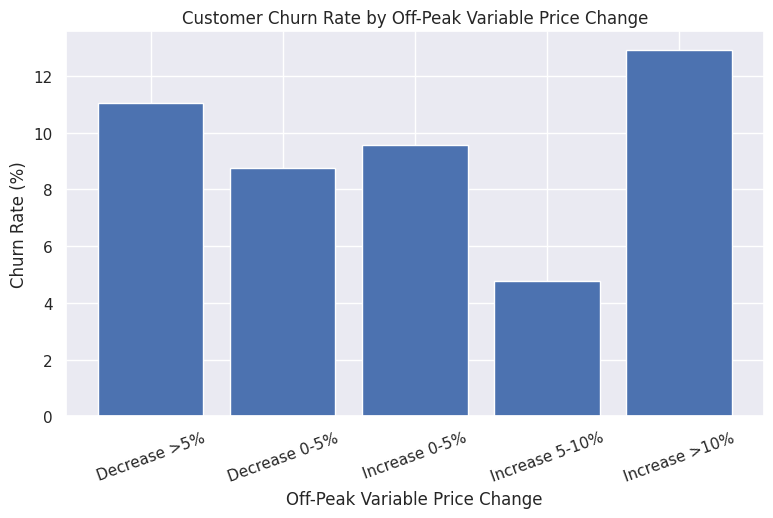

In [ ]:
# Convert the price date column to datetime
price_data["price_date"] = pd.to_datetime(price_data["price_date"])

# We use off-peak variable price as the first-pass price proxy because it is
# usage-based and broadly available across customers. We cannot yet build a
# weighted effective price because time-of-use consumption weights are unavailable.

# Reshape the data so each customer has monthly off-peak variable prices
price_pivot = price_data.pivot(
    index="id",
    columns="price_date",
    values="price_off_peak_var"
)

# Pull January and December prices
jan_price = price_pivot[pd.Timestamp("2015-01-01")]
dec_price = price_pivot[pd.Timestamp("2015-12-01")]

# Calculate percentage price change
price_change = ((dec_price - jan_price) / jan_price).reset_index()

price_change.columns = ["id", "price_change"]

# Merge price change with churn outcome
price_churn = price_change.merge(
    client_data[["id", "churn"]],
    on="id",
    how="inner"
)

# Remove cases where the starting price is zero or creates invalid values
price_churn = price_churn.replace([np.inf, -np.inf], np.nan)
price_churn = price_churn.dropna(subset=["price_change"])

# Create price-change groups
bins = [-np.inf, -0.05, 0, 0.05, 0.10, np.inf]

labels = [
    "Decrease >5%",
    "Decrease 0-5%",
    "Increase 0-5%",
    "Increase 5-10%",
    "Increase >10%"
]

price_churn["price_change_group"] = pd.cut(
    price_churn["price_change"],
    bins=bins,
    labels=labels
)

# Calculate churn rate within each price-change group
churn_by_price = (
    price_churn
    .groupby("price_change_group", observed=False)["churn"]
    .mean()
    .reset_index()
)

# Convert churn rate from decimal to percentage
churn_by_price["churn_rate"] = churn_by_price["churn"] * 100

# Plot
plt.figure(figsize=(9, 5))

plt.bar(
    churn_by_price["price_change_group"].astype(str),
    churn_by_price["churn_rate"]
)

plt.xlabel("Off-Peak Variable Price Change")
plt.ylabel("Churn Rate (%)")
plt.title("Customer Churn Rate by Off-Peak Variable Price Change")

plt.xticks(rotation=20)

plt.show()

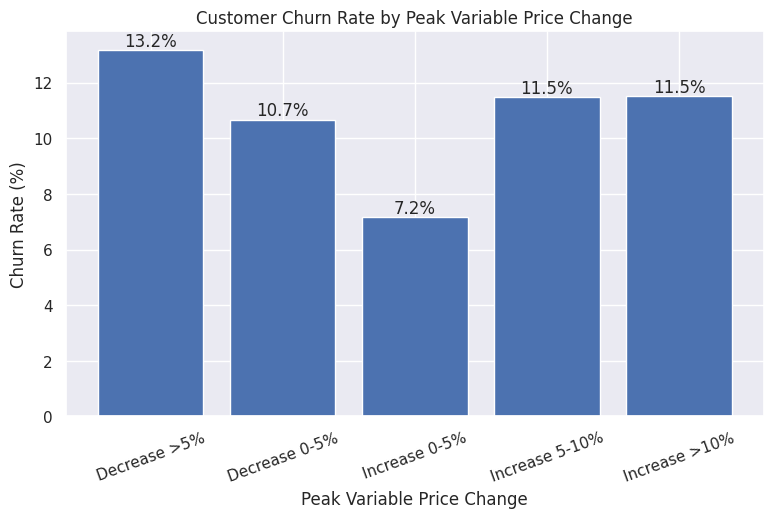

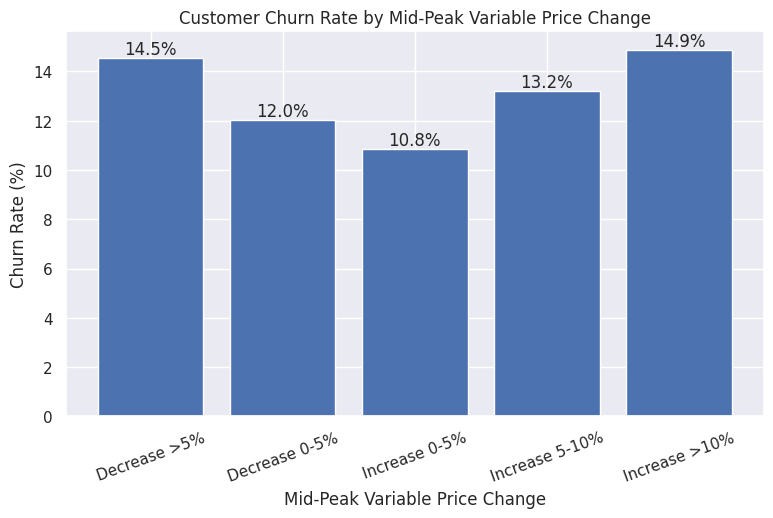

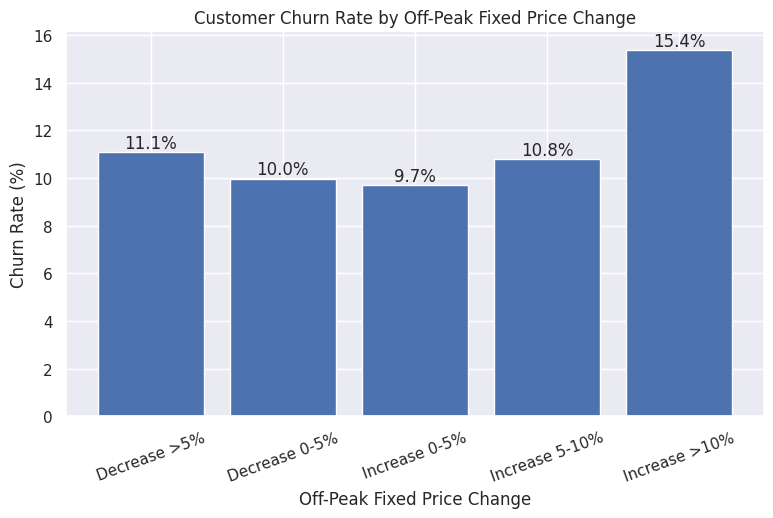

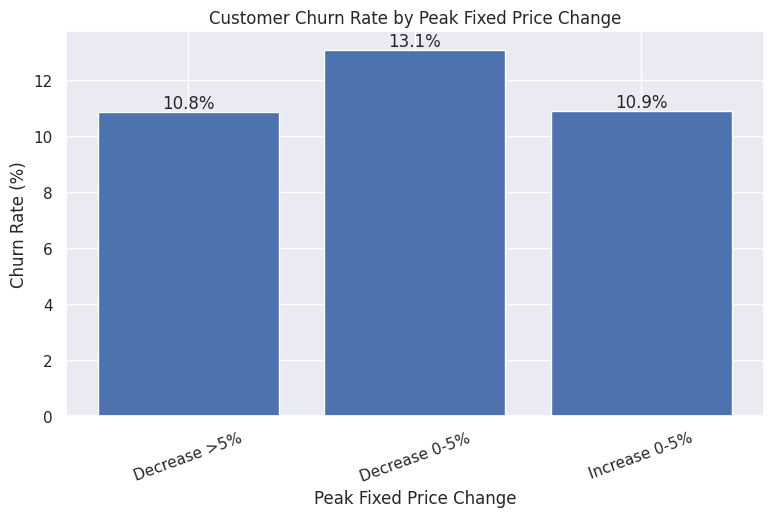

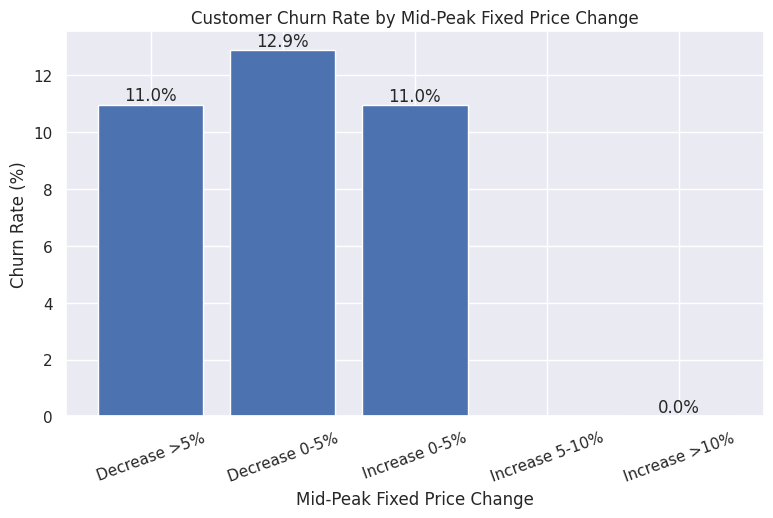

In [ ]:
# Remaining price variables to analyze
price_variables = {
    "price_peak_var": "Peak Variable Price Change",
    "price_mid_peak_var": "Mid-Peak Variable Price Change",
    "price_off_peak_fix": "Off-Peak Fixed Price Change",
    "price_peak_fix": "Peak Fixed Price Change",
    "price_mid_peak_fix": "Mid-Peak Fixed Price Change"
}

# Use the same price-change buckets as the first graph
bins = [-np.inf, -0.05, 0, 0.05, 0.10, np.inf]

labels = [
    "Decrease >5%",
    "Decrease 0-5%",
    "Increase 0-5%",
    "Increase 5-10%",
    "Increase >10%"
]

for variable, graph_label in price_variables.items():

    # Reshape data so each customer has monthly prices in one row
    price_pivot = price_data.pivot(
        index="id",
        columns="price_date",
        values=variable
    )

    # Pull January and December prices
    jan_price = price_pivot[pd.Timestamp("2015-01-01")]
    dec_price = price_pivot[pd.Timestamp("2015-12-01")]

    # Percentage change cannot be calculated properly when January price = 0,
    # so these customers are excluded from this particular price comparison.
    valid_customers = jan_price > 0

    jan_price = jan_price[valid_customers]
    dec_price = dec_price[valid_customers]

    # Calculate percentage price change
    price_change = ((dec_price - jan_price) / jan_price).reset_index()

    price_change.columns = ["id", "price_change"]

    # Merge price change with churn outcome
    price_churn = price_change.merge(
        client_data[["id", "churn"]],
        on="id",
        how="inner"
    )

    # Remove missing or invalid values
    price_churn = price_churn.replace([np.inf, -np.inf], np.nan)
    price_churn = price_churn.dropna(subset=["price_change"])

    # Put customers into price-change groups
    price_churn["price_change_group"] = pd.cut(
        price_churn["price_change"],
        bins=bins,
        labels=labels
    )

    # Calculate churn rate for each price-change group
    churn_by_price = (
        price_churn
        .groupby("price_change_group", observed=False)["churn"]
        .mean()
        .reset_index()
    )

    # Convert churn rate to percentage
    churn_by_price["churn_rate"] = churn_by_price["churn"] * 100

    # Plot
    plt.figure(figsize=(9, 5))

    bars = plt.bar(
        churn_by_price["price_change_group"].astype(str),
        churn_by_price["churn_rate"]
    )

    plt.xlabel(graph_label)
    plt.ylabel("Churn Rate (%)")
    plt.title(f"Customer Churn Rate by {graph_label}")

    plt.xticks(rotation=20)

    # Add churn percentage above each bar
    for bar in bars:
        height = bar.get_height()

        if not np.isnan(height):
            plt.text(
                bar.get_x() + bar.get_width() / 2,
                height,
                f"{height:.1f}%",
                ha="center",
                va="bottom"
            )

    plt.show()

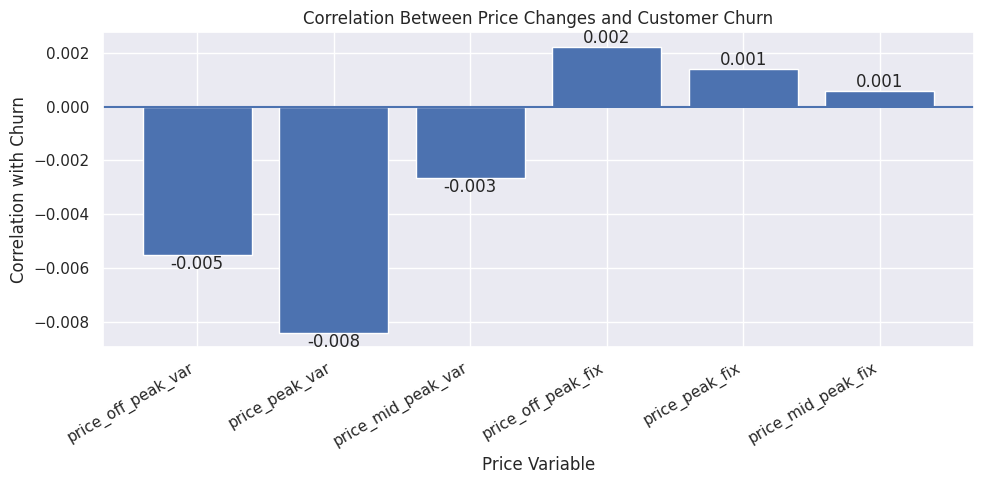

In [ ]:
plt.figure(figsize=(10, 5))

bars = plt.bar(
    correlation_results["price_variable"],
    correlation_results["correlation"]
)

plt.axhline(0)

plt.xlabel("Price Variable")
plt.ylabel("Correlation with Churn")
plt.title("Correlation Between Price Changes and Customer Churn")

plt.xticks(rotation=30, ha="right")

for bar, corr, p in zip(
    bars,
    correlation_results["correlation"],
    correlation_results["p_value"]
):

    significance = "*" if p < 0.05 else ""

    plt.text(
        bar.get_x() + bar.get_width()/2,
        corr,
        f"{corr:.3f}{significance}",
        ha="center",
        va="bottom" if corr >= 0 else "top"
    )

plt.tight_layout()
plt.show()

In [ ]:
# Create a copy so we do not modify the original client dataset
correlation_data = client_data.copy()

# Convert has_gas into a numeric binary variable
# 1 = customer has gas, 0 = customer does not have gas
correlation_data["has_gas_numeric"] = correlation_data["has_gas"].map({
    "t": 1,
    "f": 0
})

# Variables we want to compare against churn
variables = [
    "cons_12m",
    "cons_gas_12m",
    "cons_last_month",
    "forecast_cons_12m",
    "forecast_cons_year",
    "forecast_discount_energy",
    "forecast_meter_rent_12m",
    "forecast_price_energy_off_peak",
    "forecast_price_energy_peak",
    "forecast_price_pow_off_peak",
    "has_gas_numeric",
    "imp_cons",
    "margin_gross_pow_ele",
    "margin_net_pow_ele",
    "nb_prod_act",
    "net_margin",
    "num_years_antig",
    "pow_max"
]

results = []

for variable in variables:

    # Keep only rows where both the variable and churn are available
    temp = correlation_data[[variable, "churn"]].dropna()

    # Calculate correlation between the variable and churn
    correlation, p_value = pointbiserialr(
        temp["churn"],
        temp[variable]
    )

    results.append({
        "variable": variable,
        "correlation": correlation,
        "p_value": p_value
    })

# Turn results into a dataframe
customer_correlations = pd.DataFrame(results)

# Add absolute correlation so positive and negative relationships
# can be ranked by strength regardless of direction
customer_correlations["abs_correlation"] = (
    customer_correlations["correlation"].abs()
)

# Add statistical significance label
# p < 0.05 = statistically significant
customer_correlations["statistically_significant"] = np.where(
    customer_correlations["p_value"] < 0.05,
    "Yes",
    "No"
)

# Sort by strongest correlation first, regardless of direction
customer_correlations = customer_correlations.sort_values(
    by="abs_correlation",
    ascending=False
)

customer_correlations

,variable,correlation,p_value,abs_correlation,statistically_significant
13,margin_net_pow_ele,0.095772,4.111908e-31,0.095772,Yes
12,margin_gross_pow_ele,0.095725,4.392533e-31,0.095725,Yes
16,num_years_antig,-0.074140,2.917437e-19,0.074140,Yes
0,cons_12m,-0.045968,2.730117e-08,0.045968,Yes
2,cons_last_month,-0.045284,4.370505e-08,0.045284,Yes
6,forecast_meter_rent_12m,0.044245,8.825525e-08,0.044245,Yes
15,net_margin,0.041135,6.591893e-07,0.041135,Yes
1,cons_gas_12m,-0.037957,4.463684e-06,0.037957,Yes
17,pow_max,0.030362,2.426324e-04,0.030362,Yes
8,forecast_price_energy_peak,0.029315,3.950817e-04,0.029315,Yes


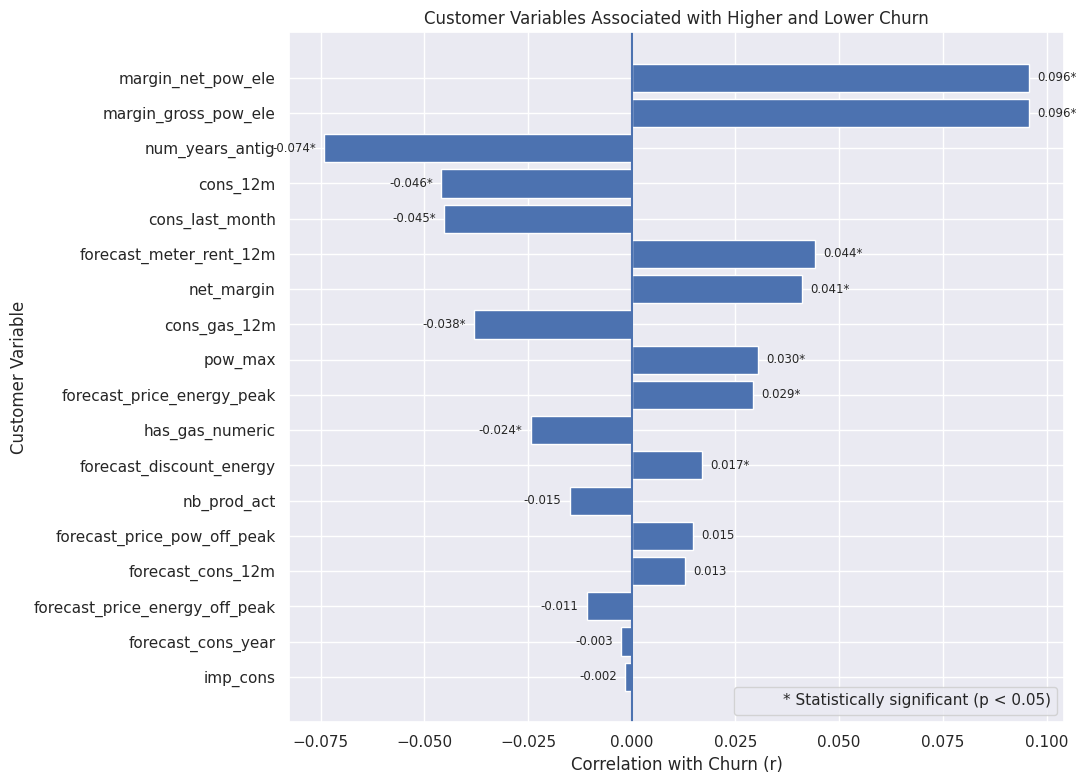

In [ ]:
from matplotlib.lines import Line2D
# Sort from weakest to strongest so the strongest correlations
# appear at the top of the horizontal chart
plot_data = customer_correlations.sort_values(
    by="abs_correlation",
    ascending=True
)

plt.figure(figsize=(11, 8))

bars = plt.barh(
    plot_data["variable"],
    plot_data["correlation"]
)

# Zero baseline
plt.axvline(
    x=0,
    linewidth=1.5
)

plt.xlabel("Correlation with Churn (r)")
plt.ylabel("Customer Variable")
plt.title("Customer Variables Associated with Higher and Lower Churn")

# Add correlation value and statistical significance
for bar, corr, p in zip(
    bars,
    plot_data["correlation"],
    plot_data["p_value"]
):

    significance = "*" if p < 0.05 else ""

    if corr >= 0:
        plt.text(
            corr + 0.002,
            bar.get_y() + bar.get_height()/2,
            f"{corr:.3f}{significance}",
            va="center",
            ha="left",
            fontsize=8.5
        )

    else:
        plt.text(
            corr - 0.002,
            bar.get_y() + bar.get_height()/2,
            f"{corr:.3f}{significance}",
            va="center",
            ha="right",
            fontsize=8.5
        )

# Add key for statistical significance
significance_key = [
    Line2D(
        [0],
        [0],
        color="none",
        marker="",
        label="* Statistically significant (p < 0.05)"
    )
]

plt.legend(
    handles=significance_key,
    loc="lower right"
)

plt.tight_layout()
plt.show()

Overall churn rate: 9.72%


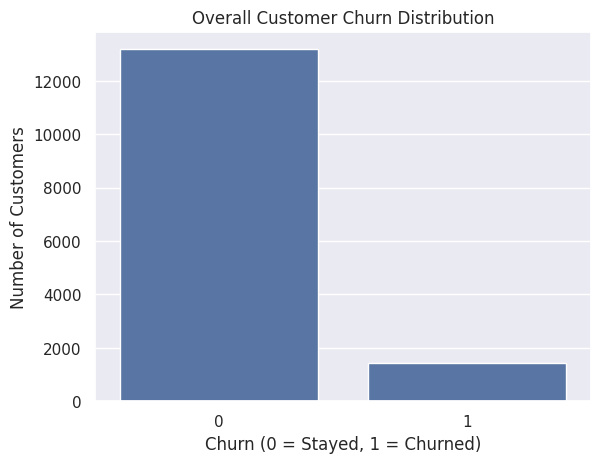


Churn rate by channel_sales:
channel_sales
foosdfpfkusacimwkcsosbicdxkicaua    12.140954
usilxuppasemubllopkaafesmlibmsdf    10.036364
ewpakwlliwisiwduibdlfmalxowmwpci     8.398656
MISSING                              7.597315
lmkebamcaaclubfxadlmueccxoimlema     5.588714
epumfxlbckeskwekxbiuasklxalciiuu     0.000000
fixdbufsefwooaasfcxdxadsiekoceaa     0.000000
sddiedcslfslkckwlfkdpoeeailfpeds     0.000000
Name: churn, dtype: float64


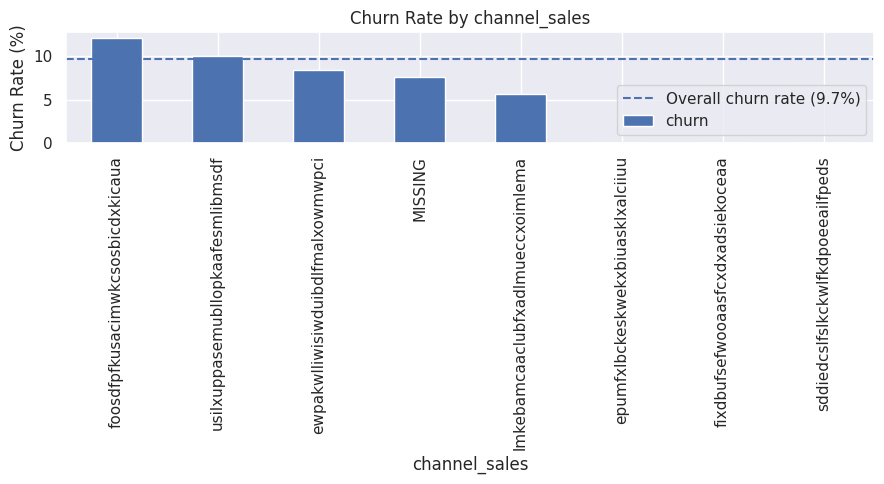


Churn rate by nb_prod_act:
nb_prod_act
4     10.000000
1      9.981629
3      9.942639
5      9.677419
2      8.507157
6      0.000000
8      0.000000
9      0.000000
10     0.000000
32     0.000000
Name: churn, dtype: float64


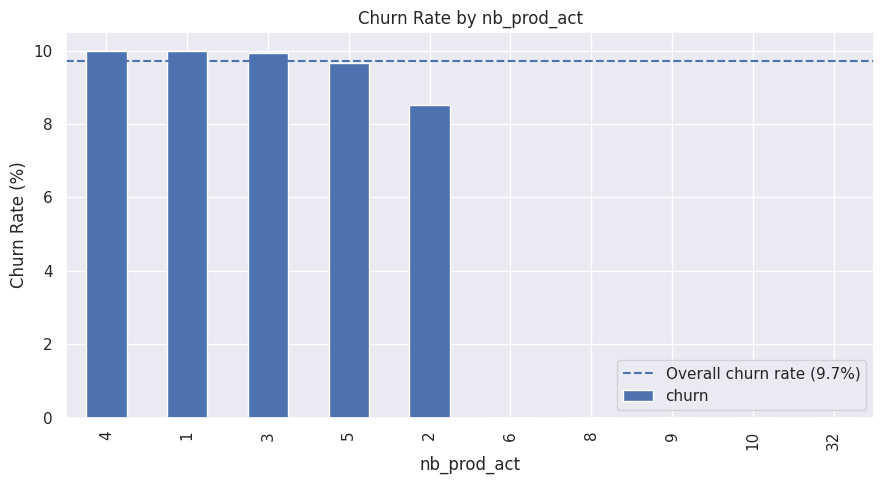


Churn rate by num_years_antig:
num_years_antig
2     27.272727
3     13.522400
4     11.853340
12    10.000000
5      8.631852
7      8.251473
13     7.692308
6      7.108408
11     6.486486
10     4.938272
8      4.854369
9      1.086957
1      0.000000
Name: churn, dtype: float64


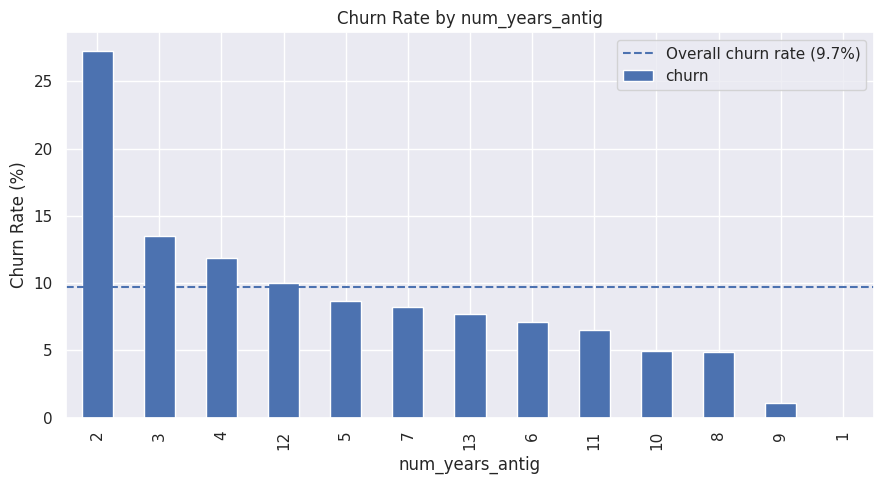


Churn rate by has_gas:
has_gas
f    10.054371
t     8.185590
Name: churn, dtype: float64


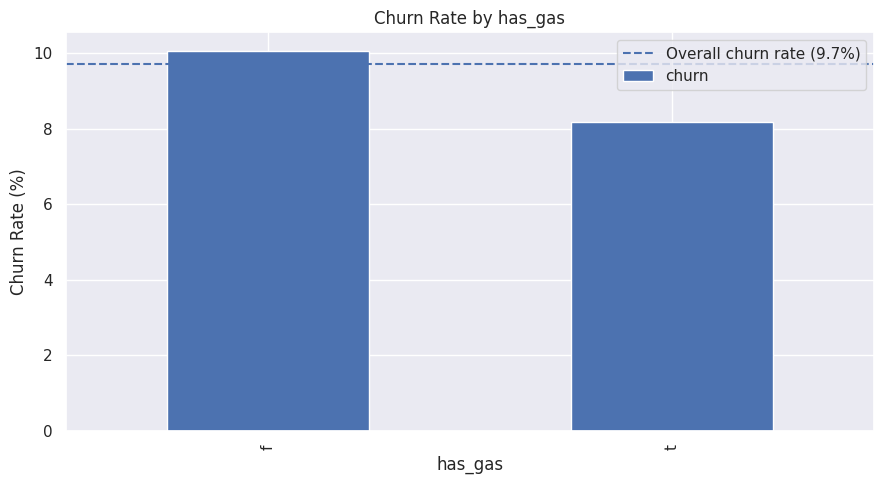


Churn rate by origin_up:
origin_up
lxidpiddsbxsbosboudacockeimpuepw    12.582781
ldkssxwpmemidmecebumciepifcamkci     8.386277
MISSING                              6.250000
kamkkxfxxuwbdslkwifmmcsiusiuosws     6.008384
ewxeelcelemmiwuafmddpobolfuxioce     0.000000
usapbepcfoloekilkwsdiboslwaxobdp     0.000000
Name: churn, dtype: float64


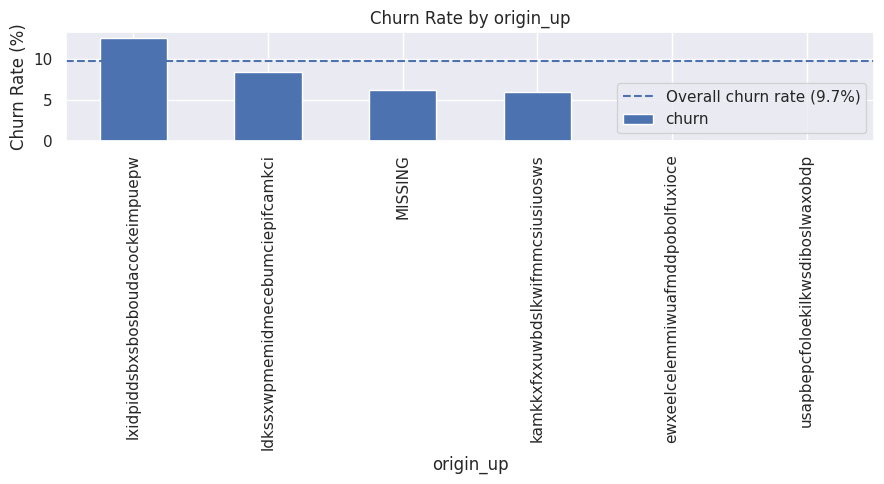

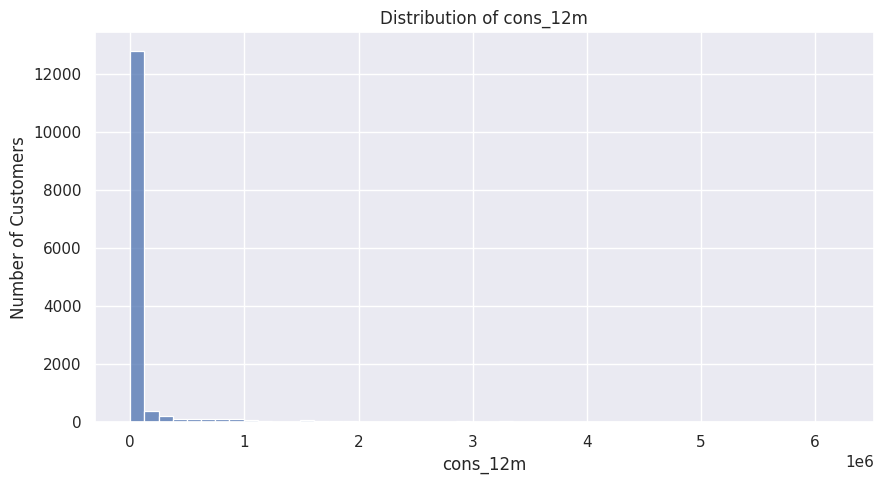

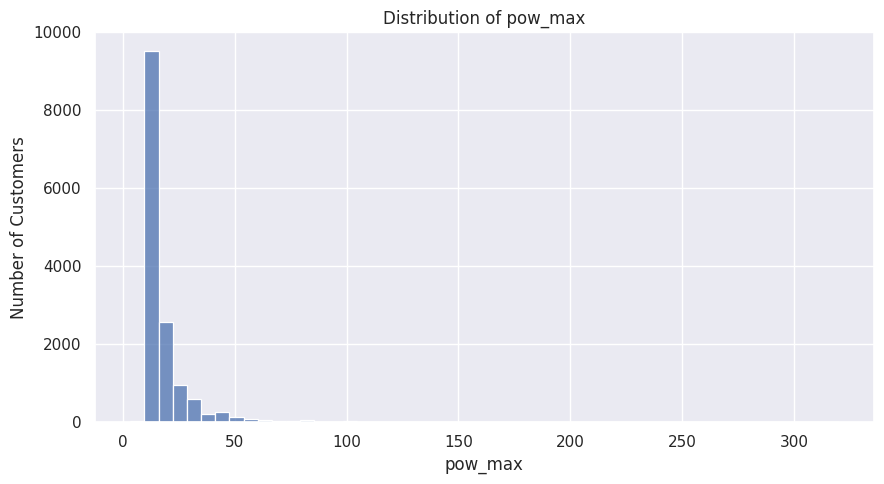

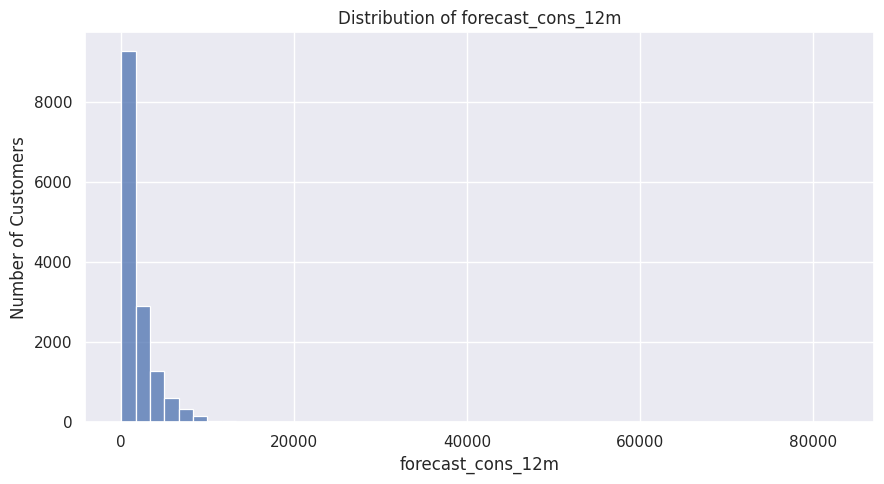

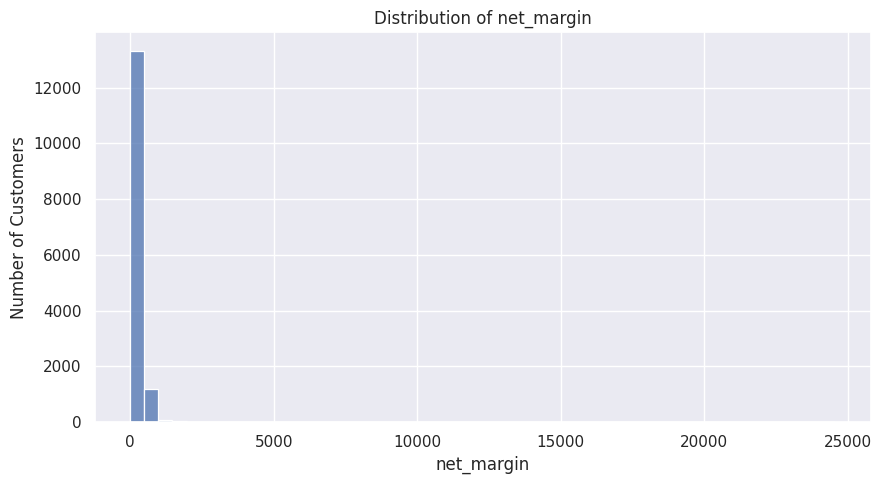

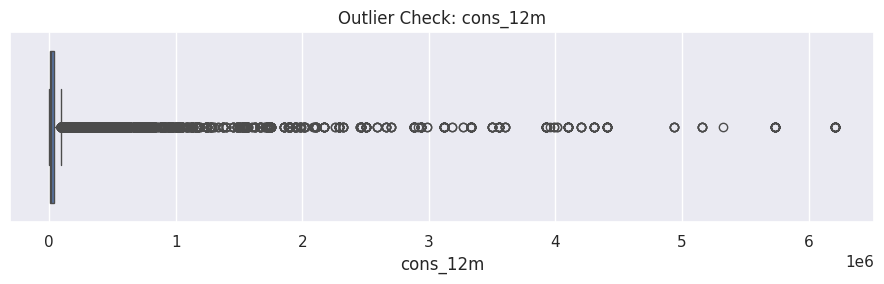

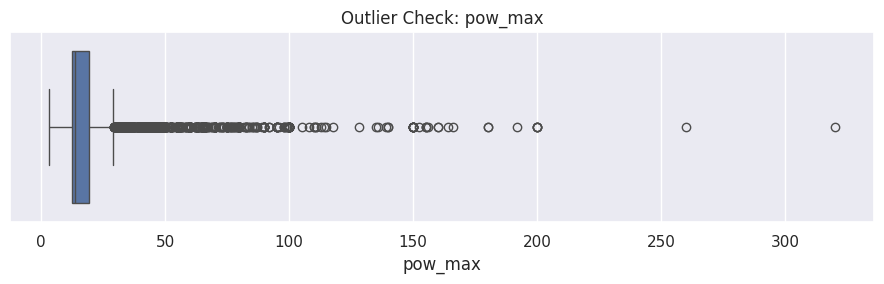

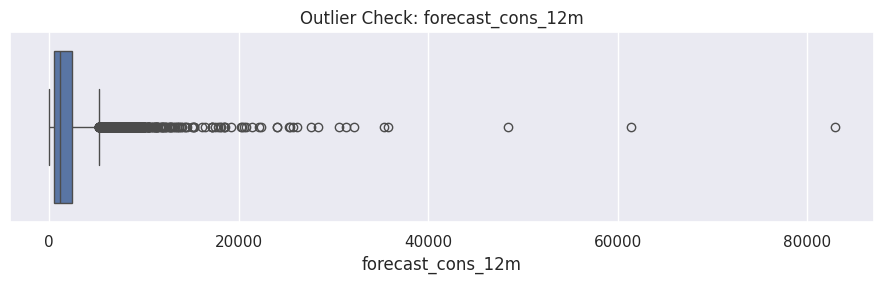

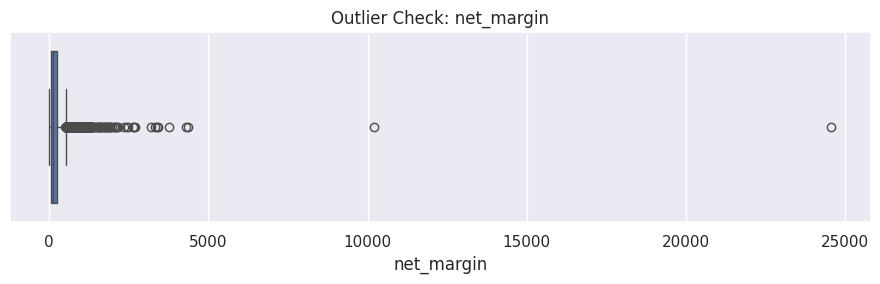


Number of unique values in each column:
churn                                 2
has_gas                               2
origin_up                             6
channel_sales                         8
nb_prod_act                          10
forecast_discount_energy             12
num_years_antig                      13
forecast_price_pow_off_peak          41
forecast_price_energy_peak          329
date_end                            368
date_renewal                        386
forecast_price_energy_off_peak      516
pow_max                             698
date_activ                         1796
cons_gas_12m                       2112
date_modif_prod                    2129
margin_gross_pow_ele               2391
margin_net_pow_ele                 2391
forecast_meter_rent_12m            3528
forecast_cons_year                 4218
cons_last_month                    4751
imp_cons                           7752
cons_12m                          11065
net_margin                        11965

In [ ]:
# ============================================================
# LOGIC TEST / DATA QUALITY CHECK
# ============================================================
# Purpose:
# Before drawing conclusions from churn correlations, we want to check
# whether the underlying variables have skewed distributions, extreme
# outliers, or unusual category patterns.
#
# Why this matters:
# A variable can appear related to churn simply because of extreme values,
# highly uneven distributions, or very small customer groups.
# This section helps confirm that the patterns we observed are interpretable.

import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# 1. OVERALL CHURN RATE
# ------------------------------------------------------------
# Quality test:
# Establish the baseline churn rate for the entire customer population.
#
# Why:
# This gives us a reference point. If overall churn is ~10%, then a subgroup
# with 15% churn is meaningfully higher, while one with 9-10% is close to normal.

overall_churn_rate = client_data["churn"].mean() * 100

print(f"Overall churn rate: {overall_churn_rate:.2f}%")

sns.countplot(data=client_data, x="churn")
plt.title("Overall Customer Churn Distribution")
plt.xlabel("Churn (0 = Stayed, 1 = Churned)")
plt.ylabel("Number of Customers")
plt.show()


# ------------------------------------------------------------
# 2. CATEGORICAL VARIABLE CHECKS
# ------------------------------------------------------------
# Quality test:
# Compare churn across customer groups such as sales channel,
# number of products, tenure, gas service, and customer origin.
#
# Why:
# This checks whether certain customer segments behave differently.
# It also helps identify categories with very few customers, where
# apparent churn differences may be unreliable.

categorical_variables = [
    "channel_sales",
    "nb_prod_act",
    "num_years_antig",
    "has_gas",
    "origin_up"
]

for variable in categorical_variables:

    churn_by_group = (
        client_data
        .groupby(variable)["churn"]
        .mean()
        .sort_values(ascending=False)
        * 100
    )

    print(f"\nChurn rate by {variable}:")
    print(churn_by_group)

    churn_by_group.plot(
        kind="bar",
        figsize=(9, 5)
    )

    plt.axhline(
        overall_churn_rate,
        linestyle="--",
        label=f"Overall churn rate ({overall_churn_rate:.1f}%)"
    )

    plt.title(f"Churn Rate by {variable}")
    plt.ylabel("Churn Rate (%)")
    plt.xlabel(variable)
    plt.legend()
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 3. NUMERIC DISTRIBUTION CHECKS
# ------------------------------------------------------------
# Quality test:
# Examine the shape of important numerical variables.
#
# Why:
# Strongly skewed variables may be dominated by a small number of large values.
# This can make averages misleading and may affect later statistical models.

numeric_variables = [
    "cons_12m",
    "pow_max",
    "forecast_cons_12m",
    "net_margin"
]

for variable in numeric_variables:

    plt.figure(figsize=(9, 5))

    sns.histplot(
        data=client_data,
        x=variable,
        bins=50
    )

    plt.title(f"Distribution of {variable}")
    plt.xlabel(variable)
    plt.ylabel("Number of Customers")
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 4. OUTLIER CHECKS
# ------------------------------------------------------------
# Quality test:
# Use boxplots to identify extreme observations.
#
# Why:
# Extreme values may represent legitimate large customers, data-entry issues,
# or unusual cases. We should identify them before using these variables
# in modeling or drawing strong conclusions from averages.

for variable in numeric_variables:

    plt.figure(figsize=(9, 3))

    sns.boxplot(
        data=client_data,
        x=variable
    )

    plt.title(f"Outlier Check: {variable}")
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 5. UNIQUE VALUE / CATEGORY SIZE CHECK
# ------------------------------------------------------------
# Quality test:
# Check how many unique values each variable contains.
#
# Why:
# Variables with only one value provide no analytical information.
# Variables with many rare categories may produce unstable churn comparisons.

print("\nNumber of unique values in each column:")
print(client_data.nunique().sort_values())


# ------------------------------------------------------------
# 6. MISSING VALUE CHECK
# ------------------------------------------------------------
# Quality test:
# Identify columns with missing data.
#
# Why:
# Missing values can reduce sample size or create bias if the missingness
# is concentrated in certain customer groups.

print("\nMissing values by column:")
print(client_data.isnull().sum().sort_values(ascending=False))

# ============================================================
# ISSUES THAT CAN IMPACT RESULTS / INTERPRETATION
# ============================================================

# - cons_12m is strongly right-skewed and contains many high-end outliers.
#   Impact: averages can overstate the typical customer's electricity consumption,
#   and extreme values may influence correlations or later model estimates.

# - pow_max is strongly right-skewed and contains high-end outliers.
#   Impact: a small number of very high-capacity customers may disproportionately
#   affect averages and some statistical relationships.

# - forecast_cons_12m is strongly right-skewed and contains large extreme values.
#   Impact: raw averages may not represent the typical customer, and extreme
#   forecast values may influence later modeling.

# - net_margin is extremely right-skewed and contains very large high-end outliers.
#   Impact: a small number of highly profitable customers can substantially distort
#   the mean and may influence correlations with churn.

# - channel_sales, origin_up, nb_prod_act, and some num_years_antig groups contain
#   very small numbers of customers.
#   Impact: churn rates for these small groups may appear extremely high or low
#   simply because one or two customers changed the percentage substantially.

# - Some pricing variables contain zero values that may represent a tariff component
#   that does not apply to a customer rather than a true price of zero.
#   Impact: treating these values as ordinary prices could distort price-change
#   calculations and comparisons with churn.

# - Statistical significance should not be interpreted as relationship strength.
#   Impact: because the dataset is large, a very small correlation may still have
#   p < 0.05. Correlation magnitude (r) and p-value should be interpreted together.

# - Correlation does not demonstrate causation.
#   Impact: findings should be presented as variables being "associated with churn,"
#   not as proven causes of churn.


# ============================================================
# FORMATTING / DATA HANDLING ISSUES
# ============================================================

# - channel_sales contains the text value "MISSING" instead of a true NaN.
#   Impact: Python treats "MISSING" as a real category unless it is explicitly
#   recoded or intentionally retained as a missing-data group.

# - origin_up contains the text value "MISSING" instead of a true NaN.
#   Impact: missing contract-origin information may be displayed or modeled as if
#   it were a genuine customer category.

# - Date variables such as date_activ, date_end, date_modif_prod, date_renewal,
#   and price_date may initially load as text/object values.
#   Impact: they should be converted to datetime format before calculating tenure,
#   renewal timing, or changes over time.

# - has_gas is stored as text values ("t" and "f").
#   Impact: it should be converted to a consistent binary format if it is used in
#   correlation analysis or predictive modeling.

# - Price data contains multiple monthly rows for each customer.
#   Impact: the data must be reshaped or summarized before it can be directly
#   compared with the one-row-per-customer client dataset.

# - client_data and price_data should remain unchanged as raw source datasets.
#   Impact: cleaned, transformed, or merged versions should be created separately
#   so that the original data can always be referenced.

In [ ]:
# Load the cleaned dataset
clean_data = pd.read_csv("/content/clean_data_after_eda.csv")

# Print the dataset
print(clean_data)

# Show the first 5 rows in a cleaner format
clean_data.head()

# Create a readable summary of every variable in the dataset

column_summary = pd.DataFrame({
    "Variable": clean_data.columns,
    "Data Type": clean_data.dtypes.astype(str).values,
    "Missing Values": clean_data.isnull().sum().values,
    "Unique Values": clean_data.nunique().values
})

column_summary

                                     id                     channel_sales  \
0      24011ae4ebbe3035111d65fa7c15bc57  foosdfpfkusacimwkcsosbicdxkicaua   
1      d29c2c54acc38ff3c0614d0a653813dd                           MISSING   
2      764c75f661154dac3a6c254cd082ea7d  foosdfpfkusacimwkcsosbicdxkicaua   
3      bba03439a292a1e166f80264c16191cb  lmkebamcaaclubfxadlmueccxoimlema   
4      149d57cf92fc41cf94415803a877cb4b                           MISSING   
...                                 ...                               ...   
14601  18463073fb097fc0ac5d3e040f356987  foosdfpfkusacimwkcsosbicdxkicaua   
14602  d0a6f71671571ed83b2645d23af6de00  foosdfpfkusacimwkcsosbicdxkicaua   
14603  10e6828ddd62cbcf687cb74928c4c2d2  foosdfpfkusacimwkcsosbicdxkicaua   
14604  1cf20fd6206d7678d5bcafd28c53b4db  foosdfpfkusacimwkcsosbicdxkicaua   
14605  563dde550fd624d7352f3de77c0cdfcd                           MISSING   

       cons_12m  cons_gas_12m  cons_last_month  date_activ    date_end  \
0

,Variable,Data Type,Missing Values,Unique Values
0,id,object,0,14606
1,channel_sales,object,0,8
2,cons_12m,int64,0,11065
3,cons_gas_12m,int64,0,2112
4,cons_last_month,int64,0,4751
5,date_activ,object,0,1796
6,date_end,object,0,368
7,date_modif_prod,object,0,2129
8,date_renewal,object,0,386
9,forecast_cons_12m,float64,0,13993


Final dataset shape: (14606, 69)

Remaining non-numeric columns:
['id']

Columns with missing values:
recent_consumption_ratio      117
net_margin_per_consumption    117
dtype: int64


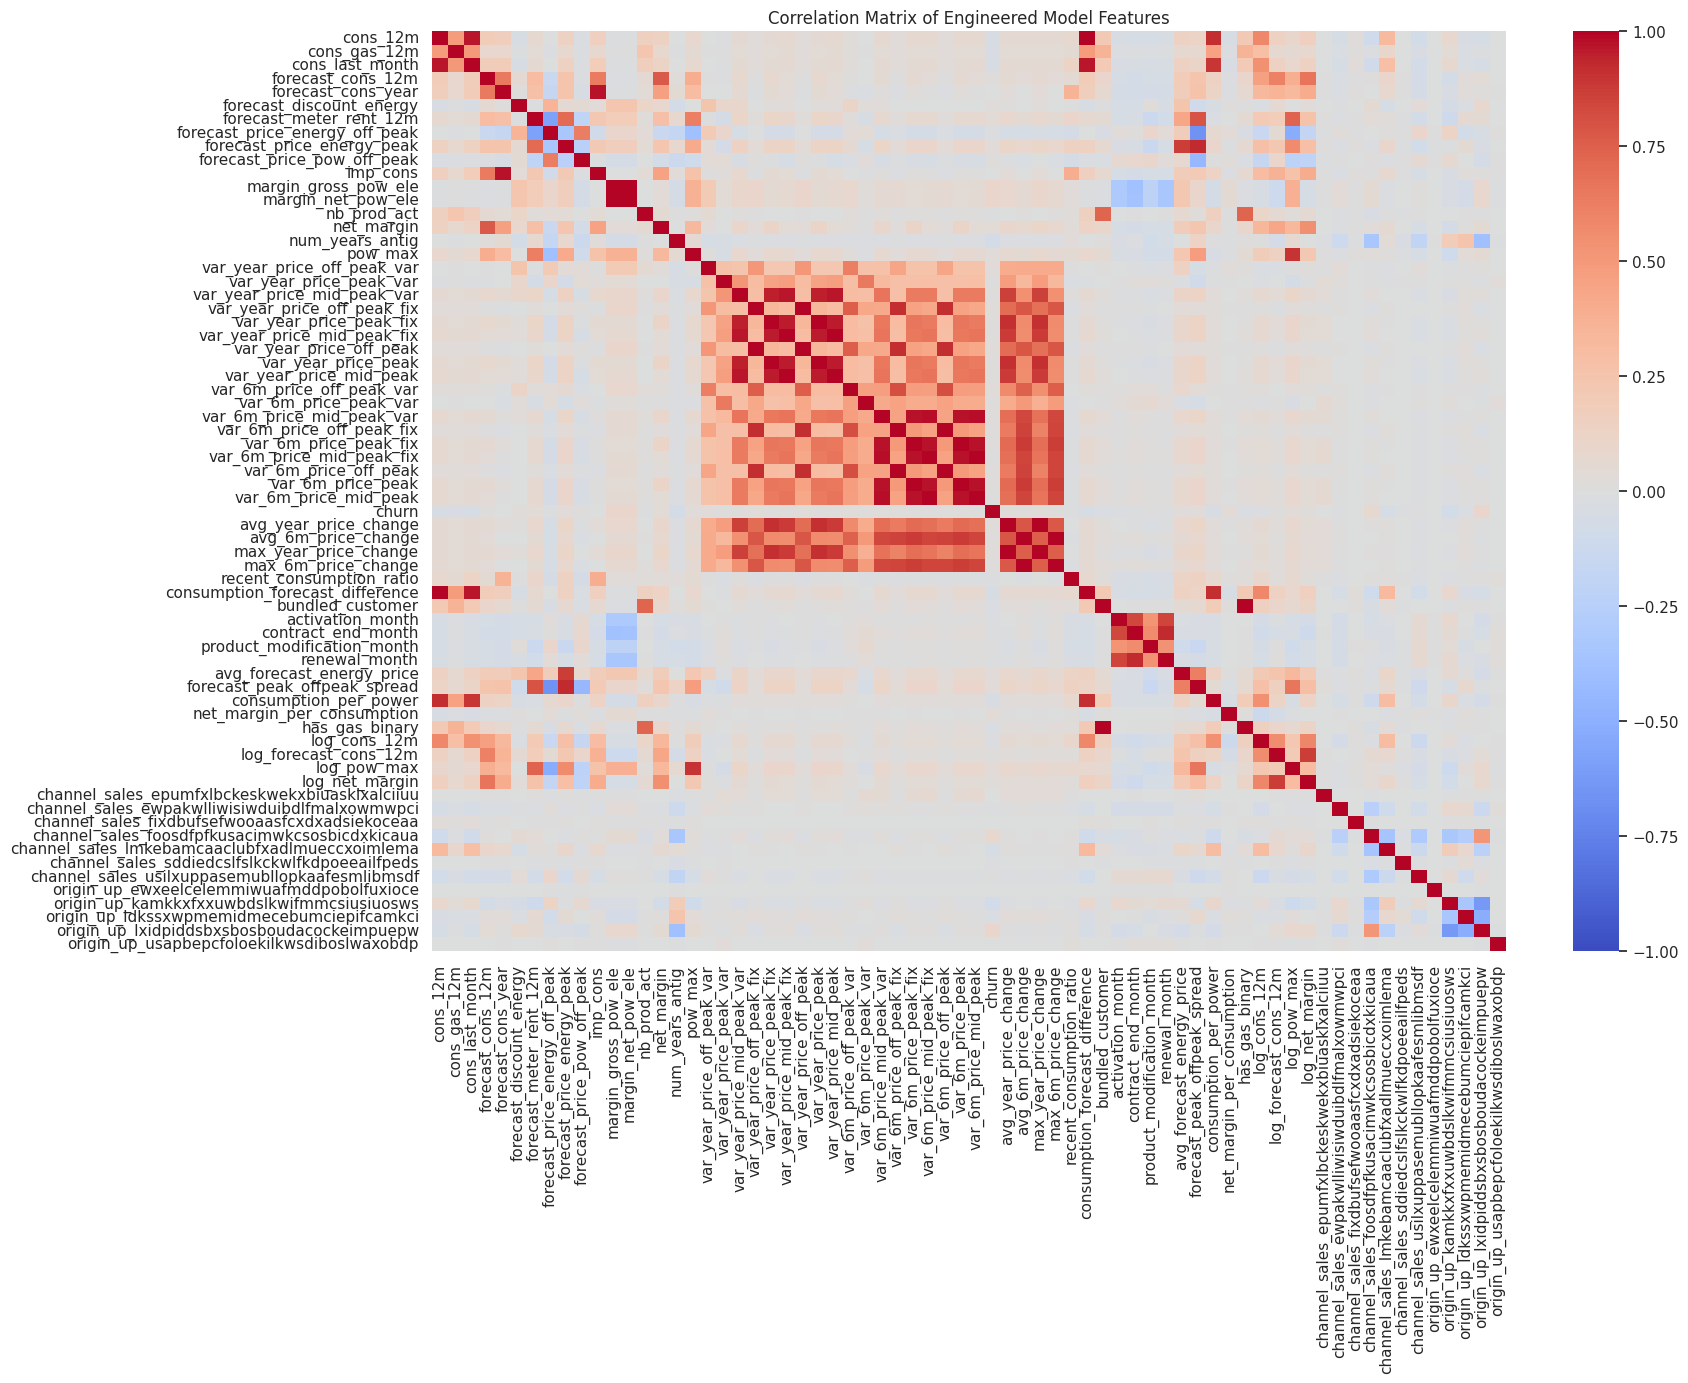


Highly correlated feature pairs (|r| >= 0.90):


,Feature 1,Feature 2,Absolute Correlation
1961,bundled_customer,has_gas_binary,1.000000
1614,var_6m_price_mid_peak_fix,var_6m_price_mid_peak,1.000000
1245,var_year_price_mid_peak_fix,var_year_price_mid_peak,1.000000
1539,var_6m_price_off_peak_fix,var_6m_price_off_peak,1.000000
1199,var_year_price_peak_fix,var_year_price_peak,1.000000
1577,var_6m_price_peak_fix,var_6m_price_peak,1.000000
1152,var_year_price_off_peak_fix,var_year_price_off_peak,1.000000
40,cons_12m,consumption_forecast_difference,0.999992
682,margin_gross_pow_ele,margin_net_pow_ele,0.999914
1814,avg_6m_price_change,max_6m_price_change,0.995472


In [ ]:
# ============================================================
# FEATURE ENGINEERING
# ============================================================
# Goal:
# Create new model-ready features from the cleaned customer dataset.
# The engineered features are organized into the four feature-engineering
# categories: Addition, Deletion, Combination, and Mutation.

# Work from a copy so the cleaned source dataset remains unchanged
model_data = clean_data.copy()


# ============================================================
# 1. ADDITION
# Create new features that capture useful customer behavior
# ============================================================


# ------------------------------------------------------------
# A. AVERAGE YEARLY PRICE CHANGE
# Uses:
# var_year_price_off_peak
# var_year_price_peak
# var_year_price_mid_peak
#
# Purpose:
# Represents the customer's average price change across off-peak,
# peak, and mid-peak periods over the year.
#
# Why useful:
# Instead of using three separate yearly price-change variables,
# this summarizes the customer's overall annual price movement.
# ------------------------------------------------------------

model_data["avg_year_price_change"] = model_data[
    [
        "var_year_price_off_peak",
        "var_year_price_peak",
        "var_year_price_mid_peak"
    ]
].mean(axis=1)


# ------------------------------------------------------------
# B. AVERAGE 6-MONTH PRICE CHANGE
# Uses:
# var_6m_price_off_peak
# var_6m_price_peak
# var_6m_price_mid_peak
#
# Purpose:
# Represents the customer's average price change across pricing
# periods during the most recent 6-month period.
#
# Why useful:
# This gives the model a more recent measure of overall price movement.
# ------------------------------------------------------------

model_data["avg_6m_price_change"] = model_data[
    [
        "var_6m_price_off_peak",
        "var_6m_price_peak",
        "var_6m_price_mid_peak"
    ]
].mean(axis=1)


# ------------------------------------------------------------
# C. MAXIMUM YEARLY PRICE CHANGE
# Uses:
# var_year_price_off_peak
# var_year_price_peak
# var_year_price_mid_peak
#
# Purpose:
# Captures the largest price movement experienced by a customer
# across off-peak, peak, and mid-peak periods during the year.
#
# Why useful:
# A customer may react more strongly to one large price change than
# to their average price change across the year.
# ------------------------------------------------------------

model_data["max_year_price_change"] = model_data[
    [
        "var_year_price_off_peak",
        "var_year_price_peak",
        "var_year_price_mid_peak"
    ]
].abs().max(axis=1)


# ------------------------------------------------------------
# D. MAXIMUM 6-MONTH PRICE CHANGE
# Uses:
# var_6m_price_off_peak
# var_6m_price_peak
# var_6m_price_mid_peak
#
# Purpose:
# Captures the largest recent price movement experienced by a
# customer during the six-month period.
#
# Why useful:
# This can represent a recent price shock that may be more relevant
# to churn than a yearly average.
# ------------------------------------------------------------

model_data["max_6m_price_change"] = model_data[
    [
        "var_6m_price_off_peak",
        "var_6m_price_peak",
        "var_6m_price_mid_peak"
    ]
].abs().max(axis=1)


# ------------------------------------------------------------
# E. RECENT CONSUMPTION RATIO
# Uses:
# cons_last_month
# cons_12m
#
# Purpose:
# Compares the customer's most recent monthly consumption with their
# average monthly consumption over the previous 12 months.
#
# Interpretation:
# > 1 = recent usage is above the customer's annual monthly average
# < 1 = recent usage is below the customer's annual monthly average
# ------------------------------------------------------------

model_data["recent_consumption_ratio"] = (
    model_data["cons_last_month"] /
    (model_data["cons_12m"] / 12).replace(0, np.nan)
)


# ------------------------------------------------------------
# F. ACTUAL VS FORECAST CONSUMPTION DIFFERENCE
# Uses:
# cons_12m
# forecast_cons_12m
#
# Purpose:
# Measures how different actual annual consumption is from forecast
# annual consumption.
#
# Why useful:
# Large differences may indicate changing customer behavior that is
# not captured by either variable independently.
# ------------------------------------------------------------

model_data["consumption_forecast_difference"] = (
    model_data["cons_12m"] -
    model_data["forecast_cons_12m"]
)


# ------------------------------------------------------------
# G. BUNDLED CUSTOMER
# Uses:
# has_gas
# nb_prod_act
#
# Purpose:
# Identifies customers who have gas service and more than one active product.
#
# Why useful:
# This represents customer relationship depth rather than treating gas
# service and product count completely independently.
# ------------------------------------------------------------

model_data["bundled_customer"] = (
    (model_data["has_gas"] == "t") &
    (model_data["nb_prod_act"] > 1)
).astype(int)



# ============================================================
# 2. DELETION
# Remove raw fields after extracting more useful information
# ============================================================


# ------------------------------------------------------------
# A. RAW DATE COLUMNS
# Uses originally:
# date_activ
# date_end
# date_modif_prod
# date_renewal
#
# Reason for removal:
# Raw calendar dates cannot be used directly by many machine-learning
# algorithms and are less meaningful than engineered month variables.
#
# Important:
# Month information is created below BEFORE these columns are dropped.
# ------------------------------------------------------------

date_columns = [
    "date_activ",
    "date_end",
    "date_modif_prod",
    "date_renewal"
]

for col in date_columns:
    model_data[col] = pd.to_datetime(model_data[col])


# Create month features before deleting raw dates
model_data["activation_month"] = model_data["date_activ"].dt.month
model_data["contract_end_month"] = model_data["date_end"].dt.month
model_data["product_modification_month"] = model_data["date_modif_prod"].dt.month
model_data["renewal_month"] = model_data["date_renewal"].dt.month


# Raw dates are no longer needed after extracting month information
model_data = model_data.drop(columns=date_columns)


# ------------------------------------------------------------
# B. CUSTOMER ID
#
# id is intentionally NOT deleted yet.
#
# Reason:
# It is still useful for checking customers, merging datasets, and
# tracing errors.
#
# It should be removed immediately before model training because the
# identifier itself should not predict churn.
# ------------------------------------------------------------



# ============================================================
# 3. COMBINATION
# Combine related columns into clearer business concepts
# ============================================================


# ------------------------------------------------------------
# A. AVERAGE FORECAST ENERGY PRICE
# Uses:
# forecast_price_energy_off_peak
# forecast_price_energy_peak
#
# Purpose:
# Provides a broad summary of the customer's forecast variable energy price.
#
# Limitation:
# This is an unweighted average because customer consumption is not
# available separately for each time-of-use period.
# ------------------------------------------------------------

model_data["avg_forecast_energy_price"] = model_data[
    [
        "forecast_price_energy_off_peak",
        "forecast_price_energy_peak"
    ]
].mean(axis=1)


# ------------------------------------------------------------
# B. FORECAST PEAK/OFF-PEAK PRICE SPREAD
# Uses:
# forecast_price_energy_peak
# forecast_price_energy_off_peak
#
# Purpose:
# Measures the difference between peak and off-peak forecast prices.
#
# Why useful:
# Customers with a large pricing spread may have a different price
# experience from customers whose prices are relatively similar.
# ------------------------------------------------------------

model_data["forecast_peak_offpeak_spread"] = (
    model_data["forecast_price_energy_peak"] -
    model_data["forecast_price_energy_off_peak"]
)


# ------------------------------------------------------------
# C. CONSUMPTION PER SUBSCRIBED POWER
# Uses:
# cons_12m
# pow_max
#
# Purpose:
# Measures annual consumption relative to maximum subscribed power.
#
# Why useful:
# This distinguishes customers who actually use their available capacity
# heavily from customers who simply have a large power subscription.
# ------------------------------------------------------------

model_data["consumption_per_power"] = (
    model_data["cons_12m"] /
    model_data["pow_max"].replace(0, np.nan)
)


# ------------------------------------------------------------
# D. NET MARGIN PER UNIT OF CONSUMPTION
# Uses:
# net_margin
# cons_12m
#
# Purpose:
# Measures customer profitability relative to electricity consumption.
#
# Why useful:
# This separates customers who are profitable because of high volume
# from customers who generate more margin per unit consumed.
# ------------------------------------------------------------

model_data["net_margin_per_consumption"] = (
    model_data["net_margin"] /
    model_data["cons_12m"].replace(0, np.nan)
)



# ============================================================
# 4. MUTATION
# Transform existing columns into model-friendly formats
# ============================================================


# ------------------------------------------------------------
# A. BOOLEAN TO BINARY
# Uses:
# has_gas
#
# Purpose:
# Converts the text values "t" and "f" into numeric values.
#
# 1 = customer has gas
# 0 = customer does not have gas
#
# Why useful:
# Statistical and machine-learning models require numeric input.
# ------------------------------------------------------------

model_data["has_gas_binary"] = model_data["has_gas"].map({
    "t": 1,
    "f": 0
})


# ------------------------------------------------------------
# B. LOG TRANSFORM ANNUAL CONSUMPTION
# Uses:
# cons_12m
#
# Purpose:
# cons_12m was strongly right-skewed during EDA.
#
# Why useful:
# The logarithm compresses extremely large observations and creates
# a distribution that may be easier for some models to use.
# ------------------------------------------------------------

model_data["log_cons_12m"] = np.log1p(
    model_data["cons_12m"]
)


# ------------------------------------------------------------
# C. LOG TRANSFORM FORECAST CONSUMPTION
# Uses:
# forecast_cons_12m
#
# Purpose:
# forecast_cons_12m was strongly right-skewed.
#
# Why useful:
# Reduces the influence of extreme forecast values.
# ------------------------------------------------------------

model_data["log_forecast_cons_12m"] = np.log1p(
    model_data["forecast_cons_12m"]
)


# ------------------------------------------------------------
# D. LOG TRANSFORM SUBSCRIBED POWER
# Uses:
# pow_max
#
# Purpose:
# pow_max has a right-skewed distribution and high-end outliers.
#
# Why useful:
# Compresses unusually large values while preserving their ordering.
# ------------------------------------------------------------

model_data["log_pow_max"] = np.log1p(
    model_data["pow_max"]
)


# ------------------------------------------------------------
# E. LOG TRANSFORM NET MARGIN
# Uses:
# net_margin
#
# Purpose:
# net_margin was extremely right-skewed during EDA.
#
# Why useful:
# Reduces the influence of a small number of exceptionally high-margin
# customers.
# ------------------------------------------------------------

model_data["log_net_margin"] = np.log1p(
    model_data["net_margin"]
)


# ------------------------------------------------------------
# F. CATEGORICAL VARIABLES TO DUMMY VARIABLES
# Uses:
# channel_sales
# origin_up
#
# Purpose:
# These columns contain categories rather than numerical values.
#
# Dummy variables create a separate 0/1 indicator for each category.
#
# Example:
# channel_sales_A = 1 when customer belongs to channel A
# channel_sales_A = 0 otherwise
#
# drop_first=True removes one reference category from each variable
# to reduce redundant information.
# ------------------------------------------------------------

model_data = pd.get_dummies(
    model_data,
    columns=[
        "channel_sales",
        "origin_up"
    ],
    drop_first=True,
    dtype=int
)


# ------------------------------------------------------------
# G. REMOVE ORIGINAL BOOLEAN TEXT COLUMN
#
# has_gas is no longer needed because has_gas_binary now contains
# the same information numerically.
# ------------------------------------------------------------

model_data = model_data.drop(columns=["has_gas"])



# ============================================================
# FINAL FEATURE QUALITY CHECK
# ============================================================


# ------------------------------------------------------------
# A. CHECK RESULTING DATASET
# ------------------------------------------------------------

print("Final dataset shape:", model_data.shape)

print("\nRemaining non-numeric columns:")
print(
    model_data
    .select_dtypes(exclude=np.number)
    .columns
    .tolist()
)


# ------------------------------------------------------------
# B. CHECK MISSING VALUES CREATED DURING FEATURE ENGINEERING
#
# Ratios can create NaN values when the denominator is zero.
# These should be identified before training the model.
# ------------------------------------------------------------

print("\nColumns with missing values:")
missing_after_engineering = (
    model_data
    .isnull()
    .sum()
)

print(
    missing_after_engineering[
        missing_after_engineering > 0
    ].sort_values(ascending=False)
)


# ------------------------------------------------------------
# C. FEATURE-TO-FEATURE CORRELATION CHECK
#
# Purpose:
# This is different from the earlier correlation-to-churn analysis.
#
# Here we check whether predictor variables are highly correlated
# with EACH OTHER.
#
# Why useful:
# If two features have correlations close to +1 or -1, they may contain
# nearly identical information. One may eventually be removable to
# reduce unnecessary model complexity.
# ------------------------------------------------------------

numeric_model_data = model_data.select_dtypes(include=np.number)

feature_correlation_matrix = numeric_model_data.corr()

plt.figure(figsize=(18, 14))

sns.heatmap(
    feature_correlation_matrix,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1
)

plt.title("Correlation Matrix of Engineered Model Features")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# D. IDENTIFY VERY HIGHLY CORRELATED FEATURE PAIRS
#
# Threshold:
# Absolute correlation >= 0.90
#
# Purpose:
# Produces a readable list of features that may contain highly
# redundant information and could be candidates for removal later.
# ------------------------------------------------------------

corr_matrix_abs = feature_correlation_matrix.abs()

upper_triangle = corr_matrix_abs.where(
    np.triu(
        np.ones(corr_matrix_abs.shape),
        k=1
    ).astype(bool)
)

high_correlation_pairs = (
    upper_triangle
    .stack()
    .reset_index()
)

high_correlation_pairs.columns = [
    "Feature 1",
    "Feature 2",
    "Absolute Correlation"
]

high_correlation_pairs = high_correlation_pairs[
    high_correlation_pairs["Absolute Correlation"] >= 0.90
].sort_values(
    "Absolute Correlation",
    ascending=False
)

print("\nHighly correlated feature pairs (|r| >= 0.90):")
display(high_correlation_pairs)

Number of customers: 14606
Number of model features: 67

Non-numeric columns remaining:
[]

Missing values remaining: 0

Churn counts:
churn
0    13187
1     1419
Name: count, dtype: int64

Churn rate: 9.72 %

Training customers: 11684
Testing customers: 2922
Training churn rate: 9.71 %
Testing churn rate: 9.72 %

RANDOM FOREST PERFORMANCE
-------------------------
Accuracy: 0.91
Precision: 0.8889
Recall: 0.0845
F1 Score: 0.1543
ROC-AUC: 0.7149

Confusion Matrix:


,Predicted Stay,Predicted Churn
Actual Stay,2635,3
Actual Churn,260,24



Classification Report:
              precision    recall  f1-score   support

      Stayed       0.91      1.00      0.95      2638
     Churned       0.89      0.08      0.15       284

    accuracy                           0.91      2922
   macro avg       0.90      0.54      0.55      2922
weighted avg       0.91      0.91      0.87      2922



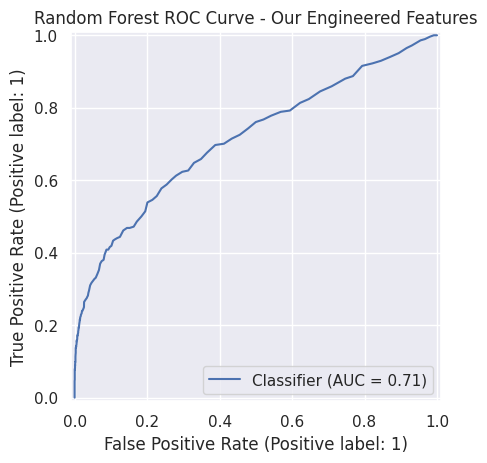


Top 15 Most Important Features:


,Feature,Importance
12,margin_net_pow_ele,0.044812
11,margin_gross_pow_ele,0.044230
6,forecast_meter_rent_12m,0.039617
49,net_margin_per_consumption,0.037352
48,consumption_per_power,0.032862
0,cons_12m,0.031690
51,log_cons_12m,0.031425
40,consumption_forecast_difference,0.031313
54,log_net_margin,0.029101
14,net_margin,0.029076


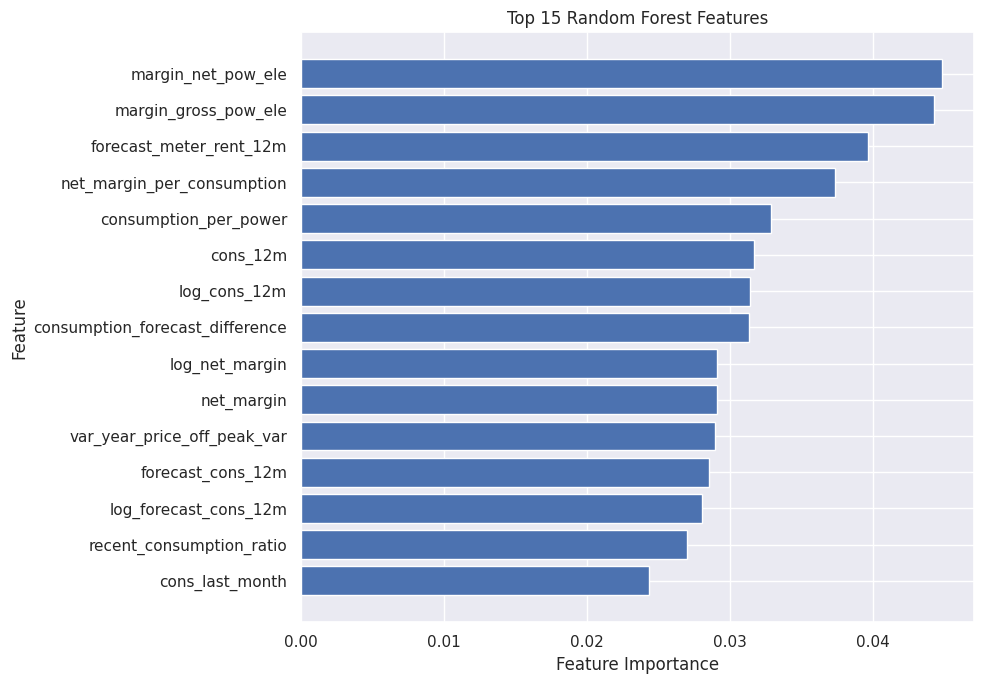

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)


# ============================================================
# 1. DEFINE TARGET
# ============================================================

# churn is the outcome we are trying to predict:
# 0 = customer stayed
# 1 = customer churned
y = model_data["churn"]


# ============================================================
# 2. DEFINE MODEL FEATURES
# ============================================================

# Start with every engineered feature in model_data.
# Remove churn because it is the target.
# Remove id because it is only a customer identifier.

X = model_data.drop(
    columns=[
        "churn",
        "id"
    ]
).copy()


# If an accidental CSV index column exists, remove it.
if "Unnamed: 0" in X.columns:
    X = X.drop(columns=["Unnamed: 0"])


print("Number of customers:", len(X))
print("Number of model features:", X.shape[1])


# ============================================================
# 3. VERIFY THAT ALL FEATURES ARE NUMERIC
# ============================================================

# Dates, has_gas, channel_sales, and origin_up were already transformed
# during feature engineering, so the model should now contain only
# numeric variables.

non_numeric_columns = X.select_dtypes(
    exclude=np.number
).columns.tolist()

print("\nNon-numeric columns remaining:")
print(non_numeric_columns)


# Stop if something unexpected remains.
if len(non_numeric_columns) > 0:
    raise ValueError(
        f"These columns are still non-numeric: {non_numeric_columns}"
    )


# ============================================================
# 4. HANDLE VALUES CREATED BY FEATURE ENGINEERING
# ============================================================

# Ratio features can occasionally create infinity when dividing by zero.
# Convert those values to missing values first.
X = X.replace(
    [np.inf, -np.inf],
    np.nan
)


# Fill missing values using each feature's median.
# Median is appropriate here because several original variables
# were highly skewed and contained large outliers.
X = X.fillna(
    X.median()
)


# Confirm that the model matrix is now complete.
print(
    "\nMissing values remaining:",
    X.isna().sum().sum()
)


# ============================================================
# 5. CHECK CHURN BALANCE
# ============================================================

print("\nChurn counts:")
print(y.value_counts())

print(
    "\nChurn rate:",
    round(y.mean() * 100, 2),
    "%"
)


# ============================================================
# 6. TRAIN / TEST SPLIT
# ============================================================

# 80% of customers train the model.
# 20% are held back to evaluate performance.
#
# stratify=y preserves the churn percentage in both groups.
# random_state=42 makes the comparison reproducible.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


print("\nTraining customers:", len(X_train))
print("Testing customers:", len(X_test))

print(
    "Training churn rate:",
    round(y_train.mean() * 100, 2),
    "%"
)

print(
    "Testing churn rate:",
    round(y_test.mean() * 100, 2),
    "%"
)


# ============================================================
# 7. BUILD RANDOM FOREST
# ============================================================

# Use the same model settings for a fair comparison with
# Estelle's final dataset.
#
# n_estimators=300:
# Creates 300 decision trees.
#
# class_weight="balanced":
# Gives additional importance to the smaller churn class.
#
# random_state=42:
# Keeps results reproducible.
#
# n_jobs=-1:
# Uses all available processor cores.

random_forest = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)


# Train the model
random_forest.fit(
    X_train,
    y_train
)


# ============================================================
# 8. MAKE PREDICTIONS
# ============================================================

# Final classification:
# 0 = stay
# 1 = churn
y_pred = random_forest.predict(
    X_test
)


# Probability of churn for each customer.
# Used to calculate ROC-AUC.
y_probability = random_forest.predict_proba(
    X_test
)[:, 1]


# ============================================================
# 9. EVALUATE PERFORMANCE
# ============================================================

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)

roc_auc = roc_auc_score(
    y_test,
    y_probability
)


print("\nRANDOM FOREST PERFORMANCE")
print("-------------------------")

print(
    "Accuracy:",
    round(accuracy, 4)
)

print(
    "Precision:",
    round(precision, 4)
)

print(
    "Recall:",
    round(recall, 4)
)

print(
    "F1 Score:",
    round(f1, 4)
)

print(
    "ROC-AUC:",
    round(roc_auc, 4)
)


# ============================================================
# 10. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test,
    y_pred
)

confusion_matrix_df = pd.DataFrame(
    cm,
    index=[
        "Actual Stay",
        "Actual Churn"
    ],
    columns=[
        "Predicted Stay",
        "Predicted Churn"
    ]
)

print("\nConfusion Matrix:")
display(confusion_matrix_df)


# ============================================================
# 11. CLASSIFICATION REPORT
# ============================================================

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Stayed",
            "Churned"
        ],
        zero_division=0
    )
)


# ============================================================
# 12. ROC CURVE
# ============================================================

RocCurveDisplay.from_predictions(
    y_test,
    y_probability
)

plt.title(
    "Random Forest ROC Curve - Our Engineered Features"
)

plt.show()


# ============================================================
# 13. FEATURE IMPORTANCE
# ============================================================

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": random_forest.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)


print("\nTop 15 Most Important Features:")
display(
    feature_importance.head(15)
)


# ============================================================
# 14. FEATURE IMPORTANCE GRAPH
# ============================================================

top_features = (
    feature_importance
    .head(15)
    .sort_values("Importance")
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.title(
    "Top 15 Random Forest Features"
)

plt.tight_layout()
plt.show()

## Evaluation Metrics

The Random Forest classifier was evaluated using accuracy, precision, recall, F1 score, ROC-AUC, and a confusion matrix.

Accuracy measures the overall percentage of correct predictions. However, because only 9.72% of customers in the dataset churned, accuracy alone can be misleading. A model that predicts that nearly every customer will stay could still achieve high accuracy.

Precision measures how often customers predicted to churn actually churned. This is useful because low precision would result in PowerCo directing retention efforts toward many customers who were not actually likely to leave.

Recall measures the percentage of actual churners successfully identified by the model. Recall is particularly important for this problem because failing to identify a churner represents a missed opportunity for PowerCo to intervene before the customer leaves.

The F1 score combines precision and recall into a single measure and is useful for evaluating performance when the outcome classes are imbalanced.

ROC-AUC measures the model's ability to distinguish between customers who churn and customers who stay across different classification thresholds. This provides a broader assessment of the model's predictive ability than accuracy at a single threshold.

Finally, the confusion matrix was used to examine the actual numbers of correct and incorrect predictions for both churners and non-churners.

## Model Performance Assessment

The Random Forest achieved an accuracy of 91.0%, precision of 88.89%, recall of 8.45%, F1 score of 15.43%, and ROC-AUC of 0.7149.

Although the overall accuracy appears high, I would not consider the model's current classification performance satisfactory for PowerCo's churn-retention objective. The high accuracy is influenced heavily by the class imbalance, since approximately 90.3% of customers did not churn.

The confusion matrix shows that the model correctly identified 2,635 of the 2,638 customers who stayed, but identified only 24 of the 284 customers who actually churned. Therefore, 260 churners were incorrectly classified as customers who would stay.

Precision was high at 88.89%, meaning that when the model predicted churn, the prediction was usually correct. However, recall was only 8.45%, meaning the model identified fewer than one in ten actual churners. This explains the relatively low F1 score of 15.43%.

The ROC-AUC of 0.7149 is more encouraging and indicates that the model has meaningful ability to distinguish customers with higher churn risk from those with lower churn risk. This suggests that the underlying model contains useful predictive information, but the current classification approach is too conservative when identifying churners.

Overall, the model provides a useful baseline, but further optimization would be required before it could be considered effective for a customer-retention application. Potential next steps could include adjusting the probability threshold, tuning the Random Forest parameters, or further addressing the imbalance between churners and non-churners.

> ### Final Conclusion
>
> The Random Forest model provides a useful baseline for predicting customer churn, but its current performance is not yet satisfactory for a retention-focused business application.
>
> The model achieved **91.0% accuracy**, **88.89% precision**, **8.45% recall**, **15.43% F1 score**, and a **ROC-AUC of 0.7149**.
>
> The high accuracy is driven largely by the fact that most customers do not churn. The model is very precise when it predicts churn, but it identifies only **24 of 284 actual churners**, missing **260 churners** in the test set.
>
> The ROC-AUC indicates that the model does contain meaningful predictive signal, but the default classification setup is too conservative. The next step would be to improve the model's ability to identify more at-risk customers while maintaining acceptable precision.
>
> **Overall:** the model is a strong starting point for churn prediction, but further tuning and threshold optimization would be needed before using it to guide PowerCo customer-retention decisions.

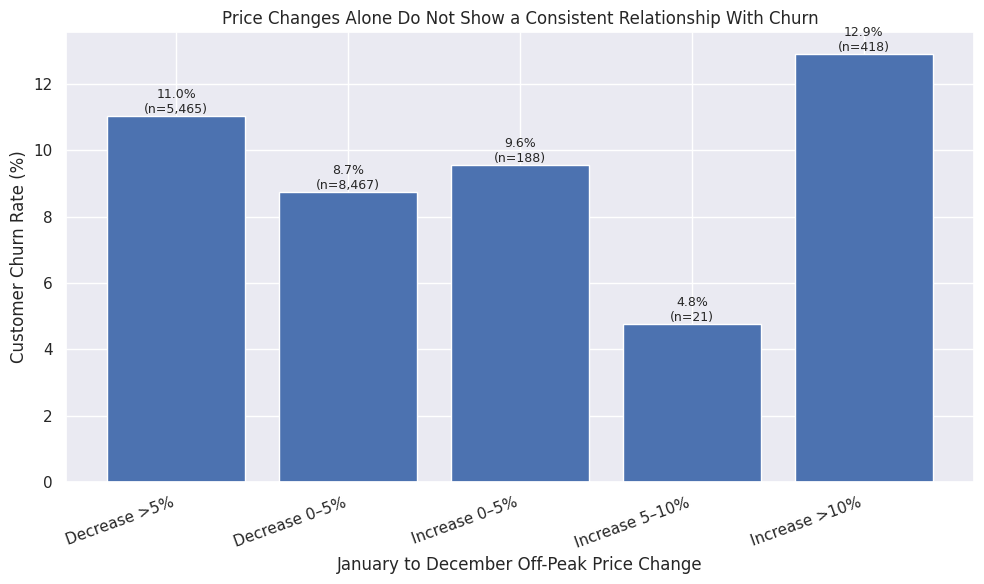

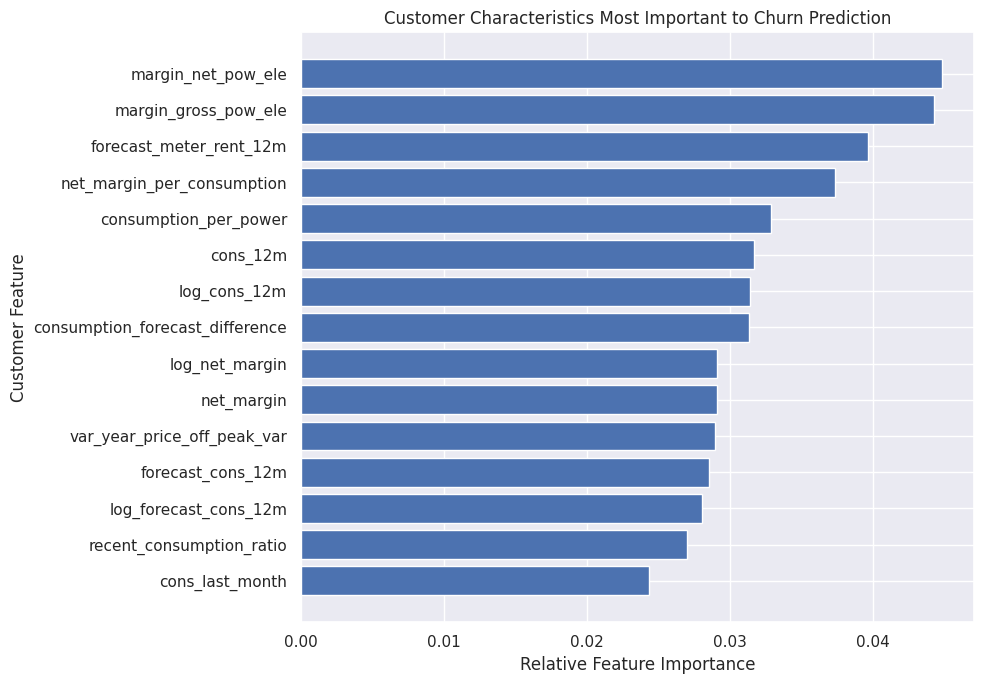

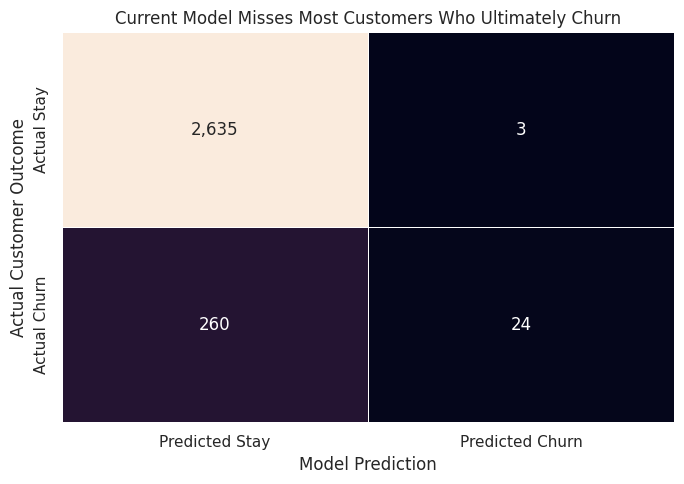

The model identified 24 of 284 actual churners (8.5%).
260 actual churners were not identified.


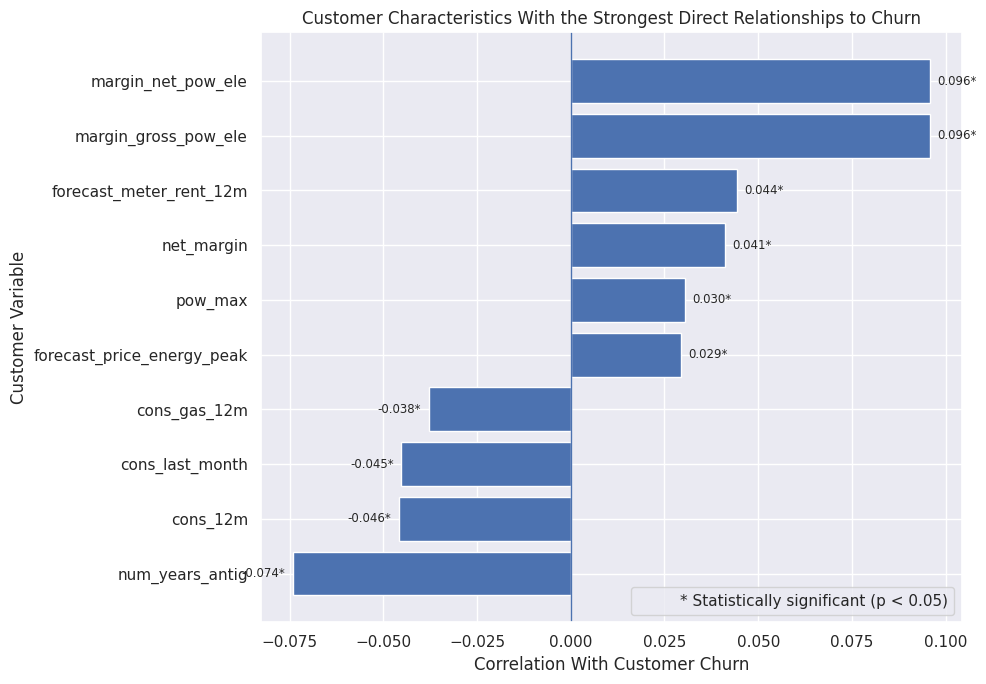

In [ ]:
# ============================================================
# BUSINESS PRESENTATION VISUALS
# ============================================================
# These four visuals summarize:
# 1. Our original price-sensitivity hypothesis
# 2. The strongest model predictors
# 3. How successfully the model identifies churners
# 4. Which individual customer characteristics relate most to churn
# ============================================================
# GRAPH 1
# CHURN RATE BY JANUARY-TO-DECEMBER OFF-PEAK PRICE CHANGE
# ============================================================
#
# Business question:
# Does increasing a customer's price appear to increase churn?
#
# Uses:
# price_data = monthly pricing dataset
# model_data = customer dataset containing churn
#
# This recreates our original price-sensitivity analysis.
# ============================================================

price_visual = price_data.copy()

price_visual["price_date"] = pd.to_datetime(
    price_visual["price_date"]
)

# January 2015 off-peak price
jan_price = (
    price_visual[
        (price_visual["price_date"].dt.year == 2015) &
        (price_visual["price_date"].dt.month == 1)
    ][["id", "price_off_peak_var"]]
    .rename(
        columns={
            "price_off_peak_var": "jan_off_peak_price"
        }
    )
)

# December 2015 off-peak price
dec_price = (
    price_visual[
        (price_visual["price_date"].dt.year == 2015) &
        (price_visual["price_date"].dt.month == 12)
    ][["id", "price_off_peak_var"]]
    .rename(
        columns={
            "price_off_peak_var": "dec_off_peak_price"
        }
    )
)

# Combine January, December, and churn outcome
price_change_analysis = (
    jan_price
    .merge(
        dec_price,
        on="id",
        how="inner"
    )
    .merge(
        model_data[
            ["id", "churn"]
        ].drop_duplicates(),
        on="id",
        how="inner"
    )
)

# Remove customers whose January price is zero because
# percentage change cannot be calculated meaningfully.
price_change_analysis = price_change_analysis[
    price_change_analysis["jan_off_peak_price"] > 0
].copy()


# January-to-December percentage change
price_change_analysis["price_pct_change"] = (
    (
        price_change_analysis["dec_off_peak_price"] -
        price_change_analysis["jan_off_peak_price"]
    )
    /
    price_change_analysis["jan_off_peak_price"]
)


# Group customers into meaningful price-change categories
price_change_analysis["price_change_group"] = pd.cut(
    price_change_analysis["price_pct_change"],
    bins=[
        -np.inf,
        -0.05,
        0,
        0.05,
        0.10,
        np.inf
    ],
    labels=[
        "Decrease >5%",
        "Decrease 0–5%",
        "Increase 0–5%",
        "Increase 5–10%",
        "Increase >10%"
    ]
)


# Calculate churn rate and sample size for each group
price_churn_summary = (
    price_change_analysis
    .groupby(
        "price_change_group",
        observed=False
    )
    .agg(
        churn_rate=("churn", "mean"),
        customers=("churn", "size")
    )
    .reset_index()
)


# Plot
plt.figure(figsize=(10, 6))

bars = plt.bar(
    price_churn_summary["price_change_group"].astype(str),
    price_churn_summary["churn_rate"] * 100
)

plt.ylabel("Customer Churn Rate (%)")
plt.xlabel("January to December Off-Peak Price Change")

plt.title(
    "Price Changes Alone Do Not Show a Consistent Relationship With Churn"
)

plt.xticks(
    rotation=20,
    ha="right"
)


# Add churn rate and sample size above each bar
for bar, churn_rate, n in zip(
    bars,
    price_churn_summary["churn_rate"],
    price_churn_summary["customers"]
):

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{churn_rate * 100:.1f}%\n(n={n:,})",
        ha="center",
        va="bottom",
        fontsize=9
    )


plt.tight_layout()
plt.show()



# ============================================================
# GRAPH 2
# TOP 15 RANDOM FOREST FEATURE IMPORTANCES
# ============================================================
#
# Business question:
# Which customer characteristics did the model rely on most
# when distinguishing higher-risk customers?
#
# Uses:
# random_forest = trained Random Forest
# X = model feature dataset
# ============================================================

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": random_forest.feature_importances_
})

feature_importance = (
    feature_importance
    .sort_values(
        "Importance",
        ascending=False
    )
)

top_features = (
    feature_importance
    .head(15)
    .sort_values(
        "Importance"
    )
)


plt.figure(figsize=(10, 7))

bars = plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Relative Feature Importance")
plt.ylabel("Customer Feature")

plt.title(
    "Customer Characteristics Most Important to Churn Prediction"
)

plt.tight_layout()
plt.show()



# ============================================================
# GRAPH 3
# CONFUSION MATRIX
# ============================================================
#
# Business question:
# Of the customers who actually churned, how many did the
# current model successfully identify?
#
# This is the clearest visual representation of the model's
# current business limitation.
# ============================================================

cm = confusion_matrix(
    y_test,
    y_pred
)

confusion_labels = pd.DataFrame(
    cm,
    index=[
        "Actual Stay",
        "Actual Churn"
    ],
    columns=[
        "Predicted Stay",
        "Predicted Churn"
    ]
)


plt.figure(figsize=(7, 5))

sns.heatmap(
    confusion_labels,
    annot=True,
    fmt=",",
    cbar=False,
    linewidths=0.5
)

plt.title(
    "Current Model Misses Most Customers Who Ultimately Churn"
)

plt.xlabel("Model Prediction")
plt.ylabel("Actual Customer Outcome")

plt.tight_layout()
plt.show()


# Print a simple executive interpretation under the graph
actual_churners = cm[1, 0] + cm[1, 1]
caught_churners = cm[1, 1]
missed_churners = cm[1, 0]

print(
    f"The model identified {caught_churners} of "
    f"{actual_churners} actual churners "
    f"({caught_churners / actual_churners * 100:.1f}%)."
)

print(
    f"{missed_churners} actual churners were not identified."
)



# ============================================================
# GRAPH 4
# CUSTOMER VARIABLES MOST CORRELATED WITH CHURN
# ============================================================
#
# Business question:
# Which individual customer characteristics have the strongest
# direct relationships with churn?
#
# This intentionally focuses on understandable customer variables
# rather than every engineered or dummy variable in the model.
#
# * indicates p < 0.05
# ============================================================

customer_variables = [
    "cons_12m",
    "cons_gas_12m",
    "cons_last_month",
    "forecast_cons_12m",
    "forecast_cons_year",
    "forecast_discount_energy",
    "forecast_meter_rent_12m",
    "forecast_price_energy_off_peak",
    "forecast_price_energy_peak",
    "forecast_price_pow_off_peak",
    "imp_cons",
    "margin_gross_pow_ele",
    "margin_net_pow_ele",
    "nb_prod_act",
    "net_margin",
    "num_years_antig",
    "pow_max",
    "has_gas_binary"
]


# Only use variables that actually exist in model_data
customer_variables = [
    variable
    for variable in customer_variables
    if variable in model_data.columns
]


correlation_results = []

for variable in customer_variables:

    temp = model_data[
        [variable, "churn"]
    ].dropna()

    # Skip variables without enough variation
    if temp[variable].nunique() > 1:

        correlation, p_value = pointbiserialr(
            temp["churn"],
            temp[variable]
        )

        correlation_results.append({
            "variable": variable,
            "correlation": correlation,
            "p_value": p_value,
            "abs_correlation": abs(correlation)
        })


customer_correlations = pd.DataFrame(
    correlation_results
)


# Select the 10 strongest direct relationships with churn
top_correlations = (
    customer_correlations
    .sort_values(
        "abs_correlation",
        ascending=False
    )
    .head(10)
    .sort_values(
        "correlation"
    )
)


plt.figure(figsize=(10, 7))

bars = plt.barh(
    top_correlations["variable"],
    top_correlations["correlation"]
)


# Zero baseline separates positive and negative associations
plt.axvline(
    0,
    linewidth=1
)


plt.xlabel("Correlation With Customer Churn")
plt.ylabel("Customer Variable")

plt.title(
    "Customer Characteristics With the Strongest Direct Relationships to Churn"
)


# Add correlation values and statistical-significance marker
for bar, correlation, p_value in zip(
    bars,
    top_correlations["correlation"],
    top_correlations["p_value"]
):

    significance = "*" if p_value < 0.05 else ""

    if correlation >= 0:

        plt.text(
            correlation + 0.002,
            bar.get_y() + bar.get_height() / 2,
            f"{correlation:.3f}{significance}",
            va="center",
            fontsize=8.5
        )

    else:

        plt.text(
            correlation - 0.002,
            bar.get_y() + bar.get_height() / 2,
            f"{correlation:.3f}{significance}",
            va="center",
            ha="right",
            fontsize=8.5
        )


# Key explaining the star
significance_key = [
    Line2D(
        [0],
        [0],
        marker="",
        linestyle="",
        label="* Statistically significant (p < 0.05)"
    )
]

plt.legend(
    handles=significance_key,
    loc="lower right"
)

plt.tight_layout()
plt.show()